# ENSAMBLE LinearSCV y Regression

Cargando y limpiando datos (versiones diversificadas)...
Vectorizando textos...
Entrenando modelos base para encontrar pesos (esto tomará un momento por la calibración interna)...


/Users/jhonvega/Documents/universidad/Aprendizaje de Maquina/project/taller_nlp/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


SVC solo  → Val: 0.2710
LR solo   → Val: 0.2692

 w_svc |   w_lr |  Val Acc
----------------------------
  0.00 |   1.00 |   0.2692 ← MEJOR
  0.05 |   0.95 |   0.2689
  0.10 |   0.90 |   0.2695 ← MEJOR
  0.15 |   0.85 |   0.2695
  0.20 |   0.80 |   0.2716 ← MEJOR
  0.25 |   0.75 |   0.2719 ← MEJOR
  0.30 |   0.70 |   0.2711
  0.35 |   0.65 |   0.2708
  0.40 |   0.60 |   0.2713
  0.45 |   0.55 |   0.2711
  0.50 |   0.50 |   0.2722 ← MEJOR
  0.55 |   0.45 |   0.2726 ← MEJOR
  0.60 |   0.40 |   0.2727 ← MEJOR
  0.65 |   0.35 |   0.2734 ← MEJOR
  0.70 |   0.30 |   0.2738 ← MEJOR
  0.75 |   0.25 |   0.2730
  0.80 |   0.20 |   0.2721
  0.85 |   0.15 |   0.2711
  0.90 |   0.10 |   0.2715
  0.95 |   0.05 |   0.2716
  1.00 |   0.00 |   0.2710

✔ Mejor ensamble: w_svc=0.70 | Val accuracy: 0.2738


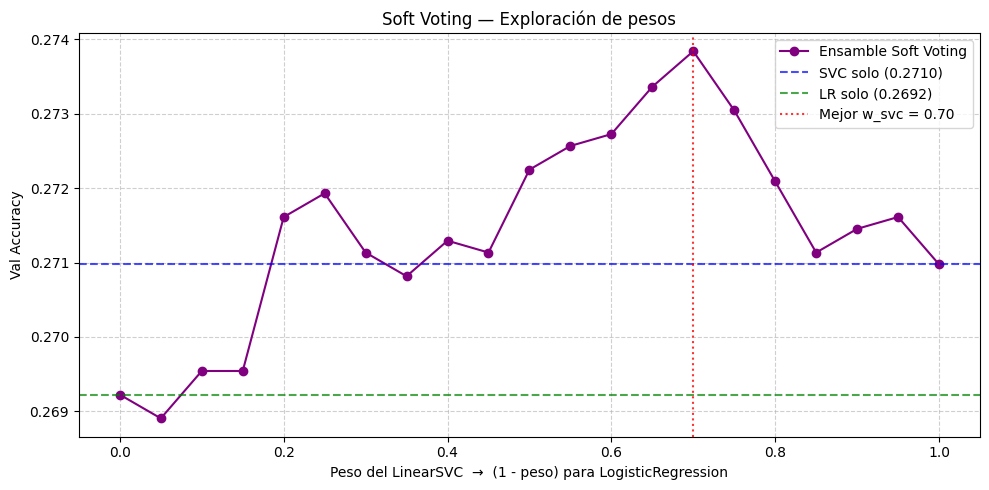


Retrenando modelo final con el 100% de los datos (esto puede tardar un poco)...


/Users/jhonvega/Documents/universidad/Aprendizaje de Maquina/project/taller_nlp/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Generando predicciones sobre eval.csv...

✔ winner_model.csv generado (3490 filas) — ¡Listo para Kaggle! 🚀


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV


def clean_svc(texto):
    """Limpieza para SVC: reemplaza ñ→n."""
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def clean_lr(texto):
    """Limpieza para LR: conserva ñ."""
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


# ── 1. CARGA Y LIMPIEZA ──────────────────────────────────────────────────────
print("Cargando y limpiando datos (versiones diversificadas)...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")

# Cada modelo recibe su propia versión del texto → diversidad real
data["text_svc"] = data["text"].apply(clean_svc)
data["text_lr"]  = data["text"].apply(clean_lr)
data_test["text_svc"] = data_test["text"].apply(clean_svc)
data_test["text_lr"]  = data_test["text"].apply(clean_lr)

y = data["decade"]

# Mismo índice de split para los dos textos → mismas muestras en val
X_svc_train, X_svc_val, y_train, y_val = train_test_split(
    data["text_svc"], y, test_size=0.2, random_state=42, stratify=y
)
X_lr_train, X_lr_val, _, _ = train_test_split(
    data["text_lr"], y, test_size=0.2, random_state=42, stratify=y
)


# ── 2. VECTORIZACIÓN SEPARADA ────────────────────────────────────────────────
print("Vectorizando textos...")
tfidf_svc = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                             max_df=0.85, min_df=2, max_features=150000,
                             lowercase=False, sublinear_tf=True)

tfidf_lr  = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                             max_df=0.85, min_df=2, max_features=150000,
                             lowercase=False, sublinear_tf=True)

X_svc_tr_v = tfidf_svc.fit_transform(X_svc_train)
X_svc_val_v = tfidf_svc.transform(X_svc_val)

X_lr_tr_v  = tfidf_lr.fit_transform(X_lr_train)
X_lr_val_v  = tfidf_lr.transform(X_lr_val)


# ── 3. ENTRENAMIENTO INDIVIDUAL (FASE DE VALIDACIÓN) ─────────────────────────
print("Entrenando modelos base para encontrar pesos (esto tomará un momento por la calibración interna)...")

svc_base = LinearSVC(C=0.5, class_weight='balanced',
                     random_state=42, max_iter=5000, dual=False)

# SOLUCIÓN AL ERROR:
# Al usar cv=3 en lugar de 'prefit', sklearn automáticamente divide el set de 
# entrenamiento (X_svc_tr_v), entrena y calibra sin causar fugas ni errores de versión.
modelo_svc = CalibratedClassifierCV(svc_base, method='sigmoid', cv=3)
modelo_svc.fit(X_svc_tr_v, y_train)

modelo_lr = LogisticRegression(penalty='l2', solver='lbfgs', C=6,
                                class_weight='balanced', random_state=42,
                                max_iter=5000)
modelo_lr.fit(X_lr_tr_v, y_train)

acc_svc = accuracy_score(y_val, modelo_svc.predict(X_svc_val_v))
acc_lr  = accuracy_score(y_val, modelo_lr.predict(X_lr_val_v))
print(f"SVC solo  → Val: {acc_svc:.4f}")
print(f"LR solo   → Val: {acc_lr:.4f}")


# ── 4. BÚSQUEDA DE PESOS ÓPTIMOS ─────────────────────────────────────────────
prob_svc = modelo_svc.predict_proba(X_svc_val_v)
prob_lr  = modelo_lr.predict_proba(X_lr_val_v)
clases   = modelo_svc.classes_

pesos       = np.arange(0.0, 1.05, 0.05)
mejor_acc   = 0
mejor_w_svc = 0.5
historia    = []

print(f"\n{'w_svc':>6} | {'w_lr':>6} | {'Val Acc':>8}")
print("-" * 28)
for w in pesos:
    prob_e = w * prob_svc + (1 - w) * prob_lr
    acc    = accuracy_score(y_val, clases[np.argmax(prob_e, axis=1)])
    historia.append(acc)
    marca  = " ← MEJOR" if acc > mejor_acc else ""
    print(f"{w:>6.2f} | {1-w:>6.2f} | {acc:>8.4f}{marca}")
    if acc > mejor_acc:
        mejor_acc, mejor_w_svc = acc, w

print(f"\n✔ Mejor ensamble: w_svc={mejor_w_svc:.2f} | Val accuracy: {mejor_acc:.4f}")


# ── 5. GRÁFICA ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(pesos, historia, marker='o', color='purple', label='Ensamble Soft Voting')
plt.axhline(acc_svc, color='blue',  linestyle='--', alpha=0.7, label=f'SVC solo ({acc_svc:.4f})')
plt.axhline(acc_lr,  color='green', linestyle='--', alpha=0.7, label=f'LR solo ({acc_lr:.4f})')
plt.axvline(mejor_w_svc, color='red', linestyle=':', alpha=0.8,
            label=f'Mejor w_svc = {mejor_w_svc:.2f}')
plt.title("Soft Voting — Exploración de pesos")
plt.xlabel("Peso del LinearSVC  →  (1 - peso) para LogisticRegression")
plt.ylabel("Val Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# ── 6. MODELO FINAL + CSV PARA KAGGLE ────────────────────────────────────────
print("\nRetrenando modelo final con el 100% de los datos (esto puede tardar un poco)...")
mejor_w_lr = round(1.0 - mejor_w_svc, 2)

tfidf_svc_f = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_df=0.85, min_df=2, max_features=150000,
                               lowercase=False, sublinear_tf=True)
tfidf_lr_f  = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_df=0.85, min_df=2, max_features=150000,
                               lowercase=False, sublinear_tf=True)

X_full_svc = tfidf_svc_f.fit_transform(data["text_svc"])
X_full_lr  = tfidf_lr_f.fit_transform(data["text_lr"])

svc_base_f = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=5000, dual=False)
svc_cal_f = CalibratedClassifierCV(svc_base_f, method='sigmoid', cv=3)
svc_cal_f.fit(X_full_svc, y) 

lr_f = LogisticRegression(penalty='l2', solver='lbfgs', C=6,
                           class_weight='balanced', random_state=42, max_iter=5000)
lr_f.fit(X_full_lr, y)

print("Generando predicciones sobre eval.csv...")
prob_test = (mejor_w_svc * svc_cal_f.predict_proba(tfidf_svc_f.transform(data_test["text_svc"]))
           + mejor_w_lr  * lr_f.predict_proba(tfidf_lr_f.transform(data_test["text_lr"])))

predicciones = svc_cal_f.classes_[np.argmax(prob_test, axis=1)]

pd.DataFrame({"id": data_test["id"], "answer": predicciones}) \
  .to_csv("winner_model.csv", index=False)

print(f"\n✔ winner_model.csv generado ({len(data_test)} filas) — ¡Listo para Kaggle! 🚀")

# ENSAMBLE DE LOS TRES MODELOS (SOFT) - GEMINI

In [ ]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import itertools

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler

# =============================================================================
# 1. FUNCIONES DE LIMPIEZA DE TEXTO (Para SVC y LR)
# =============================================================================
def cleant_text_svc(texto):
    """Limpieza optimizada para LinearSVC (Reemplaza ñ -> n)"""
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def cleant_text_lr(texto):
    """Limpieza optimizada para LogisticRegression"""
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r'[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ’\s]', ' ', texto)    
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# =============================================================================
# 2. DEFINICIÓN DE SÍMBOLOS Y EXPRESIONES REGULARES (Para Random Forest)
# =============================================================================
SIMBOLOS_FRECUENTES = [
    ',', '.', '-', '^', ':', ';', "'", '*', '(', '»',
    '/', '?', ')', '¿', '>', '«', '¡', '!', '|', '&',
    '¬', '<', '£', '"', '—', '$', '•', '\\', 'ſ', '[',
    '=', '\u2018', ']', '%', '■', '\u201c', '©', '}', '€', '{',
    '°', '„', '#', '+', '®', '\u201d', '\u2019', '_'
]
SIMBOLOS_MEDIEVALES = [
    'ꝛ', '§', '~', '⁊', 'ẽ', 'ũ', '⸗', 'õ', '™', 'ã', '♦'
]
TODOS_SIMBOLOS = SIMBOLOS_FRECUENTES + SIMBOLOS_MEDIEVALES

def nombre_columna(simbolo):
    nombres = {
        ',': 'sim_coma', '.': 'sim_punto', '-': 'sim_guion', '^': 'sim_caret',
        ':': 'sim_dos_puntos', ';': 'sim_punto_coma', "'": 'sim_apostrofe', '*': 'sim_asterisco',
        '(': 'sim_paren_abrir', '»': 'sim_guillemet_der', '/': 'sim_barra', '?': 'sim_interrogacion',
        ')': 'sim_paren_cerrar', '¿': 'sim_interrogacion_es', '>': 'sim_mayor', '«': 'sim_guillemet_izq',
        '¡': 'sim_exclamacion_es', '!': 'sim_exclamacion', '|': 'sim_barra_vertical', '&': 'sim_ampersand',
        '¬': 'sim_silabeo', '<': 'sim_menor', '£': 'sim_libra', '"': 'sim_comilla_doble',
        '—': 'sim_raya', '$': 'sim_dolar', '•': 'sim_viñeta', '\\': 'sim_barra_inversa',
        'ſ': 'sim_s_larga', '[': 'sim_corchete_abrir', '=': 'sim_igual', '\u2018': 'sim_comilla_izq',
        ']': 'sim_corchete_cerrar', '%': 'sim_porcentaje', '■': 'sim_cuadrado', '\u201c': 'sim_comilla_doble_izq',
        '©': 'sim_copyright', '}': 'sim_llave_cerrar', '€': 'sim_euro', '{': 'sim_llave_abrir',
        '°': 'sim_grado', '„': 'sim_comilla_baja', '#': 'sim_almohadilla', '+': 'sim_mas',
        '®': 'sim_marca_reg', '\u201d': 'sim_comilla_doble_der', '\u2019': 'sim_comilla_der', '_': 'sim_guion_bajo',
        'ꝛ': 'sim_r_medieval', '§': 'sim_seccion', '~': 'sim_tilde', '⁊': 'sim_tironian_et',
        'ẽ': 'sim_e_tilde', 'ũ': 'sim_u_tilde', '⸗': 'sim_guion_doble', 'õ': 'sim_o_tilde',
        '™': 'sim_trademark', 'ã': 'sim_a_tilde', '♦': 'sim_rombo',
    }
    return nombres.get(simbolo, f'sim_{ord(simbolo)}')

COLUMNAS_SIMBOLOS = [nombre_columna(s) for s in TODOS_SIMBOLOS]

PALABRAS_ARCAICAS = re.compile(
    r'\b(?:efto|efta|eftos|eftas|dize|diziendo|dixo|hazer|fazer|dezir|cofa|'
    r'cofas|mifmo|mifma|afsi|affi|tambien|efpañ\w*|efcriv\w*|efcrib\w*|'
    r'vueftra|vueflra|vueftro|merced|feñor|feñora|ombre|fobre|fiempre|'
    r'defpues|aunque|donde|quando|porque|agora|anfi|afi|anſi)\b', re.IGNORECASE
)
PALABRAS_LATINAS = re.compile(
    r'\b\w+(?:ibus|orum|arum|onis|atis|ens|antis|um|us|is|ae)\b', re.IGNORECASE
)
NUMEROS_ROMANOS = re.compile(
    r'\b(M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3}))\b',
    re.IGNORECASE
)
ABREVIATURAS      = re.compile(r'\b[a-záéíóúüñ]{1,5}\.')
U_COMO_V          = re.compile(r'\bv[aeiouáéíóú]', re.IGNORECASE)
J_POR_X           = re.compile(
    r'\b(?:di[jx]o|ba[jx]o|me[jx]or|de[jx]ar|de[jx]ó|hi[jx]o|'
    r'mu[jx]er|tra[jx]|[jx]unto|[jx]ugar|[jx]uzgar|[jx]uicio)\b',
    re.IGNORECASE
)
MAYUS_MID_ORACION = re.compile(r'(?<![.!?\n])\s+[A-ZÁÉÍÓÚÜÑ][a-záéíóúüñ]{2,}')
CONECTORES_MODERNOS = re.compile(
    r'\b(?:sin embargo|no obstante|es decir|por lo tanto|en consecuencia|'
    r'por consiguiente|a pesar de|dado que|puesto que|ya que|'
    r'en efecto|de hecho|por otro lado|en cambio|así pues)\b',
    re.IGNORECASE
)
VERBOS_ARCAICOS   = re.compile(
    r'\b\w+(?:edes|ades|istes|ábades|íades|áredes|éredes|íredes)\b',
    re.IGNORECASE
)
CHARS_AISLADOS    = re.compile(r'(?<!\w)\b([b-df-hj-np-tv-zB-DF-HJ-NP-TV-Z])\b(?!\w)')
F_INICIAL         = re.compile(
    r'\b(?:fab\w+|faz\w+|fij\w+|ferm\w+|ferr\w+|fiel\w+|fil\w+|'
    r'fin\w+|fue\w+|fuy\w+|fall\w+|fal\w+|fam\w+|far\w+|fat\w+|'
    r'fech\w+|fend\w+|ferv\w+|fest\w+|fid\w+|fog\w+|folg\w+|fond\w+|'
    r'font\w+|forc\w+|forn\w+|forr\w+|foy\w+|fuert\w+|fug\w+)\b',
    re.IGNORECASE
)

def extraer_features(texto):
    if not isinstance(texto, str) or len(texto) == 0:
        return [0] * (43 + len(TODOS_SIMBOLOS))

    palabras_lista  = texto.split()
    n_palabras      = max(len(palabras_lista), 1)
    n_caracteres    = len(texto)
    n_espacios      = max(texto.count(' '), 1)
    n_saltos_linea  = texto.count('\n')
    total_letras    = max(len(re.findall(r'[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', texto)), 1)
    texto_lower     = texto.lower()

    caracteres                = n_caracteres / n_palabras
    palabras                  = n_palabras
    simbolos                  = len(re.findall(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', texto)) / n_palabras
    mayusculas_count          = sum(1 for c in texto if c.isupper())
    mayusculas                = mayusculas_count / n_palabras
    oraciones                 = max(len(re.findall(r'[.!?]+', texto)), 1) / n_palabras
    longitud_promedio_palabra = np.mean([len(w) for w in palabras_lista])
    ratio_doble_espacio       = len(re.findall(r' {2,}', texto)) / n_espacios
    palabras_arcaicas_n       = len(PALABRAS_ARCAICAS.findall(texto_lower)) / n_palabras
    palabras_latinas_n        = len(PALABRAS_LATINAS.findall(texto_lower)) / n_palabras
    vocales_acentuadas_count  = len(re.findall(r'[áéíóúÁÉÍÓÚ]', texto))
    ratio_vocales_acentuadas  = vocales_acentuadas_count / total_letras
    signos_es                 = len(re.findall(r'[¡¿]', texto)) / n_palabras
    comillas_angulares        = len(re.findall(r'[«»]', texto)) / n_palabras
    guiones                   = len(re.findall(r'-', texto)) / n_palabras
    ruido_ocr                 = len(re.findall(r'[\^*|&£><@#~\\`{}[\]=]', texto)) / n_palabras

    frecuencias = Counter(texto)
    entropia = -sum((f / n_caracteres) * math.log2(f / n_caracteres)
                    for f in frecuencias.values()) if n_caracteres > 0 else 0
    diversidad_lexica     = len(set(palabras_lista)) / n_palabras
    ratio_palabras_cortas = sum(1 for w in palabras_lista if len(w) <= 3) / n_palabras

    espacios_por_palabra    = texto.count(' ') / n_palabras
    saltos_por_palabra      = n_saltos_linea / n_palabras
    tabs_por_palabra        = texto.count('\t') / n_palabras
    longitud_promedio_linea = n_caracteres / (n_saltos_linea + 1)
    cortes_guion_fin_linea  = len(re.findall(r'-\s*\n', texto)) / n_palabras
    digitos_por_palabra     = sum(1 for c in texto if c.isdigit()) / n_palabras

    ratio_numeros_romanos = len([m for m in NUMEROS_ROMANOS.findall(texto) if len(m[0]) >= 2]) / n_palabras
    ratio_abreviaturas    = len(ABREVIATURAS.findall(texto_lower)) / n_palabras
    ratio_u_como_v        = len(U_COMO_V.findall(texto_lower)) / n_palabras
    ratio_j_por_x         = len(J_POR_X.findall(texto_lower)) / n_palabras

    ratio_mayus_mid   = len(MAYUS_MID_ORACION.findall(texto)) / n_palabras
    densidad_parrafos = (len(re.findall(r'\n\s*\n', texto)) + 1) / n_palabras

    ratio_conectores_modernos = len(CONECTORES_MODERNOS.findall(texto_lower)) / n_palabras
    ratio_verbos_arcaicos     = len(VERBOS_ARCAICOS.findall(texto_lower)) / n_palabras
    conteo_e   = len(re.findall(r'\be\b', texto_lower))
    conteo_y   = len(re.findall(r'\by\b', texto_lower))
    ratio_e_vs_y    = conteo_e / (conteo_e + conteo_y + 1)
    conteo_non = len(re.findall(r'\bnon\b', texto_lower))
    conteo_no  = len(re.findall(r'\bno\b', texto_lower))
    ratio_non_vs_no = conteo_non / (conteo_non + conteo_no + 1)
    ratio_art_la    = len(re.findall(r'\bla\b', texto_lower)) / n_palabras

    ratio_chars_aislados     = len(CHARS_AISLADOS.findall(texto)) / n_palabras
    ratio_grupos_consonantes = len(re.findall(
        r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]{3,}', texto
    )) / n_palabras

    freq_palabras = Counter(palabras_lista)
    ratio_hapax   = sum(1 for f in freq_palabras.values() if f == 1) / n_palabras
    ratio_palabras_largas = sum(1 for w in palabras_lista if len(w) >= 8) / n_palabras
    oraciones_lista        = re.split(r'[.!?]+', texto)
    n_oraciones            = max(len(oraciones_lista), 1)
    ratio_oraciones_largas = sum(1 for o in oraciones_lista if len(o.split()) > 30) / n_oraciones
    ratio_tildes_sobre_mayusculas = vocales_acentuadas_count / max(mayusculas_count, 1)
    ratio_q         = texto_lower.count('q') / total_letras
    ratio_f_inicial = len(F_INICIAL.findall(texto_lower)) / n_palabras
    conteo_i_conj   = len(re.findall(r'\bi\b', texto_lower))
    conteo_y_conj   = len(re.findall(r'\by\b', texto_lower))
    ratio_i_vs_y    = conteo_i_conj / (conteo_i_conj + conteo_y_conj + 1)

    features_estilo = [
        caracteres, palabras, simbolos, mayusculas,
        oraciones, longitud_promedio_palabra,
        ratio_doble_espacio, palabras_arcaicas_n, palabras_latinas_n,
        ratio_vocales_acentuadas, signos_es, comillas_angulares,
        guiones, ruido_ocr,
        entropia, diversidad_lexica, ratio_palabras_cortas,
        espacios_por_palabra, saltos_por_palabra, tabs_por_palabra,
        longitud_promedio_linea, cortes_guion_fin_linea, digitos_por_palabra,
        ratio_numeros_romanos, ratio_abreviaturas,
        ratio_u_como_v, ratio_j_por_x,
        ratio_mayus_mid, densidad_parrafos,
        ratio_conectores_modernos, ratio_verbos_arcaicos,
        ratio_e_vs_y, ratio_non_vs_no, ratio_art_la,
        ratio_chars_aislados, ratio_grupos_consonantes,
        ratio_hapax, ratio_palabras_largas, ratio_oraciones_largas,
        ratio_tildes_sobre_mayusculas, ratio_q, ratio_f_inicial, ratio_i_vs_y,
    ]

    ratios_simbolos = [texto.count(s) / n_palabras for s in TODOS_SIMBOLOS]
    return features_estilo + ratios_simbolos

FEATURE_NAMES = [
    'caracteres', 'palabras', 'simbolos', 'mayusculas', 'oraciones',
    'longitud_promedio_palabra', 'ratio_doble_espacio', 'palabras_arcaicas',
    'palabras_latinas', 'ratio_vocales_acentuadas', 'signos_es',
    'comillas_angulares', 'guiones', 'ruido_ocr',
    'entropia', 'diversidad_lexica', 'ratio_palabras_cortas',
    'espacios_por_palabra', 'saltos_por_palabra', 'tabs_por_palabra',
    'longitud_promedio_linea', 'cortes_guion_fin_linea', 'digitos_por_palabra',
    'ratio_numeros_romanos', 'ratio_abreviaturas',
    'ratio_u_como_v', 'ratio_j_por_x',
    'ratio_mayus_mid', 'densidad_parrafos',
    'ratio_conectores_modernos', 'ratio_verbos_arcaicos',
    'ratio_e_vs_y', 'ratio_non_vs_no', 'ratio_art_la',
    'ratio_chars_aislados', 'ratio_grupos_consonantes',
    'ratio_hapax', 'ratio_palabras_largas', 'ratio_oraciones_largas',
    'ratio_tildes_sobre_mayusculas', 'ratio_q', 'ratio_f_inicial', 'ratio_i_vs_y',
] + COLUMNAS_SIMBOLOS

# =============================================================================
# 3. CARGA DE DATOS Y CONSTRUCCIÓN DE MATRICES
# =============================================================================
print("Cargando datos y generando matrices independientes...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")
y         = data["decade"]

# --- A) Textos limpios para SVC y LR ---
data["text_svc"] = data["text"].apply(cleant_text_svc)
data_test["text_svc"] = data_test["text"].apply(cleant_text_svc)

data["text_lr"] = data["text"].apply(cleant_text_lr)
data_test["text_lr"] = data_test["text"].apply(cleant_text_lr)

# --- B) Features Numéricas para Random Forest ---
feat_train = np.array(data["text"].apply(extraer_features).tolist(), dtype=np.float32)
feat_test  = np.array(data_test["text"].apply(extraer_features).tolist(), dtype=np.float32)

# =============================================================================
# 4. DATA SPLIT CONSISTENTE (Random State 42)
# =============================================================================
X_svc_tr, X_svc_val, y_train, y_val = train_test_split(
    data["text_svc"], y, test_size=0.2, random_state=42, stratify=y
)
X_lr_tr, X_lr_val, _, _ = train_test_split(
    data["text_lr"], y, test_size=0.2, random_state=42, stratify=y
)
X_rf_tr, X_rf_val, _, _ = train_test_split(
    feat_train, y, test_size=0.2, random_state=42, stratify=y
)

# =============================================================================
# 5. PODA DE FEATURES DEL RANDOM FOREST (Corte 0.0013) Y ESCALADO
# =============================================================================
print("\nSeleccionando features óptimas para Random Forest...")
scaler_sel = StandardScaler()
X_sel_s = scaler_sel.fit_transform(X_rf_tr)
rf_sel = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                min_samples_leaf=2, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_sel.fit(X_sel_s, y_train)

imp_df = pd.DataFrame({'feature': FEATURE_NAMES, 'importancia': rf_sel.feature_importances_})
features_retenidas = imp_df[imp_df['importancia'] >= 0.0013]['feature'].tolist()
indices_retenidos  = [FEATURE_NAMES.index(f) for f in features_retenidas]

X_rf_tr_podado   = X_rf_tr[:, indices_retenidos]
X_rf_val_podado  = X_rf_val[:, indices_retenidos]
feat_train_podado = feat_train[:, indices_retenidos]
feat_test_podado  = feat_test[:, indices_retenidos]

scaler_rf = StandardScaler()
X_rf_tr_s = scaler_rf.fit_transform(X_rf_tr_podado)
X_rf_val_s = scaler_rf.transform(X_rf_val_podado)

# =============================================================================
# 6. VECTORIZACIÓN DE TEXTO (TF-IDF)
# =============================================================================
print("\nVectorizando textos para LinearSVC y LogisticRegression...")
tfidf_svc = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                             max_df=0.85, min_df=2, max_features=150000,
                             lowercase=False, sublinear_tf=True)

tfidf_lr  = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                             max_df=0.85, min_df=2, max_features=150000,
                             lowercase=False, sublinear_tf=True)

X_svc_tr_v  = tfidf_svc.fit_transform(X_svc_tr)
X_svc_val_v = tfidf_svc.transform(X_svc_val)

X_lr_tr_v  = tfidf_lr.fit_transform(X_lr_tr)
X_lr_val_v = tfidf_lr.transform(X_lr_val)

# =============================================================================
# 7. ENTRENAMIENTO DE LOS 3 MODELOS BASE EN VALIDACIÓN
# =============================================================================
print("\nEntrenando los 3 modelos base...")

print(" -> Entrenando LinearSVC (C=0.5)...")
svc_base = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=5000, dual=False)
modelo_svc = CalibratedClassifierCV(svc_base, method='sigmoid', cv=3)
modelo_svc.fit(X_svc_tr_v, y_train)

print(" -> Entrenando Logistic Regression (C=6)...")
modelo_lr = LogisticRegression(penalty='l2', solver='lbfgs', C=6, class_weight='balanced', random_state=42, max_iter=5000)
modelo_lr.fit(X_lr_tr_v, y_train)

print(" -> Entrenando Random Forest (n_estimators=700)...")
modelo_rf = RandomForestClassifier(n_estimators=700, max_features='sqrt', min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
modelo_rf.fit(X_rf_tr_s, y_train)

# Exactitudes individuales
print(f"\nExactitudes Individuales en Validación:")
print(f"  LinearSVC : {accuracy_score(y_val, modelo_svc.predict(X_svc_val_v)):.4f}")
print(f"  LogReg    : {accuracy_score(y_val, modelo_lr.predict(X_lr_val_v)):.4f}")
print(f"  RandomFor : {accuracy_score(y_val, modelo_rf.predict(X_rf_val_s)):.4f}")

# =============================================================================
# 8. BÚSQUEDA DEL PESO ÓPTIMO DEL ENSAMBLE (SOFT VOTING)
# =============================================================================
print("\nBuscando los pesos óptimos del ensamble...")
prob_svc = modelo_svc.predict_proba(X_svc_val_v)
prob_lr  = modelo_lr.predict_proba(X_lr_val_v)
prob_rf  = modelo_rf.predict_proba(X_rf_val_s)
clases   = modelo_svc.classes_

mejor_acc = 0
mejores_pesos = (0, 0, 0)
historia = []

for w_svc in np.arange(0.1, 0.9, 0.1):
    for w_lr in np.arange(0.1, 0.9 - w_svc + 0.01, 0.1):
        w_rf = round(1.0 - w_svc - w_lr, 2)
        if w_rf < 0: continue
            
        prob_ensamble = (w_svc * prob_svc) + (w_lr * prob_lr) + (w_rf * prob_rf)
        pred_ensamble = clases[np.argmax(prob_ensamble, axis=1)]
        acc = accuracy_score(y_val, pred_ensamble)
        
        historia.append((w_svc, w_lr, w_rf, acc))
        if acc > mejor_acc:
            mejor_acc = acc
            mejores_pesos = (round(w_svc,1), round(w_lr,1), w_rf)

print(f"✔ Mejor Ensamble Val: {mejor_acc:.4f} con Pesos -> SVC: {mejores_pesos[0]} | LR: {mejores_pesos[1]} | RF: {mejores_pesos[2]}")

# =============================================================================
# 9. REENTRENAMIENTO FINAL (100% DATOS) Y PREDICCIÓN DE KAGGLE
# =============================================================================
print("\nReentrenando sobre el 100% del dataset...")

# Vectorizadores y Scaler finales
X_svc_full_v = tfidf_svc.fit_transform(data["text_svc"])
X_svc_test_v = tfidf_svc.transform(data_test["text_svc"])

X_lr_full_v  = tfidf_lr.fit_transform(data["text_lr"])
X_lr_test_v  = tfidf_lr.transform(data_test["text_lr"])

scaler_final = StandardScaler()
X_rf_full_s  = scaler_final.fit_transform(feat_train_podado)
X_rf_test_s  = scaler_final.transform(feat_test_podado)

# Entrenando
svc_final = CalibratedClassifierCV(LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=5000, dual=False), method='sigmoid', cv=3)
svc_final.fit(X_svc_full_v, y)

lr_final = LogisticRegression(penalty='l2', solver='lbfgs', C=6, class_weight='balanced', random_state=42, max_iter=5000)
lr_final.fit(X_lr_full_v, y)

rf_final = RandomForestClassifier(n_estimators=700, max_features='sqrt', min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_rf_full_s, y)

# Predecir Test
prob_svc_test = svc_final.predict_proba(X_svc_test_v)
prob_lr_test  = lr_final.predict_proba(X_lr_test_v)
prob_rf_test  = rf_final.predict_proba(X_rf_test_s)

prob_final_test = (mejores_pesos[0] * prob_svc_test) + (mejores_pesos[1] * prob_lr_test) + (mejores_pesos[2] * prob_rf_test)
pred_final = clases[np.argmax(prob_final_test, axis=1)]

submission = pd.DataFrame({"id": data_test["id"], "answer": pred_final})
submission.to_csv("mega_ensamble_definitivo.csv", index=False)
print(f"✔ mega_ensamble_definitivo.csv generado ({len(submission)} filas)")

Cargando datos y generando matrices independientes...

Seleccionando features óptimas para Random Forest...

Vectorizando textos para LinearSVC y LogisticRegression...

Entrenando los 3 modelos base...
 -> Entrenando LinearSVC (C=0.5)...
 -> Entrenando Logistic Regression (C=6)...


/Users/jhonvega/Documents/universidad/Aprendizaje de Maquina/project/taller_nlp/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


 -> Entrenando Random Forest (n_estimators=700)...

Exactitudes Individuales en Validación:
  LinearSVC : 0.2710
  LogReg    : 0.2721
  RandomFor : 0.2358

Buscando los pesos óptimos del ensamble...
✔ Mejor Ensamble Val: 0.3093 con Pesos -> SVC: 0.2 | LR: 0.2 | RF: 0.6

Reentrenando sobre el 100% del dataset...


# ENSAMBLE DE LOS 3 MODELOS (HARD) - GEMINI

In [1]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# =============================================================================
# 1. FUNCIONES DE LIMPIEZA DE TEXTO (Para SVC y LR)
# =============================================================================
def cleant_text_svc(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def cleant_text_lr(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r'[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ’\s]', ' ', texto)    
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# =============================================================================
# 2. EXTRACCIÓN DE FEATURES PARA RANDOM FOREST (El modelo ganador)
# =============================================================================
SIMBOLOS_FRECUENTES = [
    ',', '.', '-', '^', ':', ';', "'", '*', '(', '»',
    '/', '?', ')', '¿', '>', '«', '¡', '!', '|', '&',
    '¬', '<', '£', '"', '—', '$', '•', '\\', 'ſ', '[',
    '=', '\u2018', ']', '%', '■', '\u201c', '©', '}', '€', '{',
    '°', '„', '#', '+', '®', '\u201d', '\u2019', '_'
]
SIMBOLOS_MEDIEVALES = [
    'ꝛ', '§', '~', '⁊', 'ẽ', 'ũ', '⸗', 'õ', '™', 'ã', '♦'
]
TODOS_SIMBOLOS = SIMBOLOS_FRECUENTES + SIMBOLOS_MEDIEVALES

def nombre_columna(simbolo):
    nombres = {
        ',': 'sim_coma', '.': 'sim_punto', '-': 'sim_guion', '^': 'sim_caret',
        ':': 'sim_dos_puntos', ';': 'sim_punto_coma', "'": 'sim_apostrofe', '*': 'sim_asterisco',
        '(': 'sim_paren_abrir', '»': 'sim_guillemet_der', '/': 'sim_barra', '?': 'sim_interrogacion',
        ')': 'sim_paren_cerrar', '¿': 'sim_interrogacion_es', '>': 'sim_mayor', '«': 'sim_guillemet_izq',
        '¡': 'sim_exclamacion_es', '!': 'sim_exclamacion', '|': 'sim_barra_vertical', '&': 'sim_ampersand',
        '¬': 'sim_silabeo', '<': 'sim_menor', '£': 'sim_libra', '"': 'sim_comilla_doble',
        '—': 'sim_raya', '$': 'sim_dolar', '•': 'sim_viñeta', '\\': 'sim_barra_inversa',
        'ſ': 'sim_s_larga', '[': 'sim_corchete_abrir', '=': 'sim_igual', '\u2018': 'sim_comilla_izq',
        ']': 'sim_corchete_cerrar', '%': 'sim_porcentaje', '■': 'sim_cuadrado', '\u201c': 'sim_comilla_doble_izq',
        '©': 'sim_copyright', '}': 'sim_llave_cerrar', '€': 'sim_euro', '{': 'sim_llave_abrir',
        '°': 'sim_grado', '„': 'sim_comilla_baja', '#': 'sim_almohadilla', '+': 'sim_mas',
        '®': 'sim_marca_reg', '\u201d': 'sim_comilla_doble_der', '\u2019': 'sim_comilla_der', '_': 'sim_guion_bajo',
        'ꝛ': 'sim_r_medieval', '§': 'sim_seccion', '~': 'sim_tilde', '⁊': 'sim_tironian_et',
        'ẽ': 'sim_e_tilde', 'ũ': 'sim_u_tilde', '⸗': 'sim_guion_doble', 'õ': 'sim_o_tilde',
        '™': 'sim_trademark', 'ã': 'sim_a_tilde', '♦': 'sim_rombo',
    }
    return nombres.get(simbolo, f'sim_{ord(simbolo)}')

COLUMNAS_SIMBOLOS = [nombre_columna(s) for s in TODOS_SIMBOLOS]

PALABRAS_ARCAICAS = re.compile(r'\b(?:efto|efta|eftos|eftas|dize|diziendo|dixo|hazer|fazer|dezir|cofa|cofas|mifmo|mifma|afsi|affi|tambien|efpañ\w*|efcriv\w*|efcrib\w*|vueftra|vueflra|vueftro|merced|feñor|feñora|ombre|fobre|fiempre|defpues|aunque|donde|quando|porque|agora|anfi|afi|anſi)\b', re.IGNORECASE)
PALABRAS_LATINAS = re.compile(r'\b\w+(?:ibus|orum|arum|onis|atis|ens|antis|um|us|is|ae)\b', re.IGNORECASE)
NUMEROS_ROMANOS = re.compile(r'\b(M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3}))\b', re.IGNORECASE)
ABREVIATURAS = re.compile(r'\b[a-záéíóúüñ]{1,5}\.')
U_COMO_V = re.compile(r'\bv[aeiouáéíóú]', re.IGNORECASE)
J_POR_X = re.compile(r'\b(?:di[jx]o|ba[jx]o|me[jx]or|de[jx]ar|de[jx]ó|hi[jx]o|mu[jx]er|tra[jx]|[jx]unto|[jx]ugar|[jx]uzgar|[jx]uicio)\b', re.IGNORECASE)
MAYUS_MID_ORACION = re.compile(r'(?<![.!?\n])\s+[A-ZÁÉÍÓÚÜÑ][a-záéíóúüñ]{2,}')
CONECTORES_MODERNOS = re.compile(r'\b(?:sin embargo|no obstante|es decir|por lo tanto|en consecuencia|por consiguiente|a pesar de|dado que|puesto que|ya que|en efecto|de hecho|por otro lado|en cambio|así pues)\b', re.IGNORECASE)
VERBOS_ARCAICOS = re.compile(r'\b\w+(?:edes|ades|istes|ábades|íades|áredes|éredes|íredes)\b', re.IGNORECASE)
CHARS_AISLADOS = re.compile(r'(?<!\w)\b([b-df-hj-np-tv-zB-DF-HJ-NP-TV-Z])\b(?!\w)')
F_INICIAL = re.compile(r'\b(?:fab\w+|faz\w+|fij\w+|ferm\w+|ferr\w+|fiel\w+|fil\w+|fin\w+|fue\w+|fuy\w+|fall\w+|fal\w+|fam\w+|far\w+|fat\w+|fech\w+|fend\w+|ferv\w+|fest\w+|fid\w+|fog\w+|folg\w+|fond\w+|font\w+|forc\w+|forn\w+|forr\w+|foy\w+|fuert\w+|fug\w+)\b', re.IGNORECASE)

def extraer_features(texto):
    if not isinstance(texto, str) or len(texto) == 0:
        return [0] * (43 + len(TODOS_SIMBOLOS))

    palabras_lista  = texto.split()
    n_palabras      = max(len(palabras_lista), 1)
    n_caracteres    = len(texto)
    n_espacios      = max(texto.count(' '), 1)
    n_saltos_linea  = texto.count('\n')
    total_letras    = max(len(re.findall(r'[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', texto)), 1)
    texto_lower     = texto.lower()

    caracteres                = n_caracteres / n_palabras
    palabras                  = n_palabras
    simbolos                  = len(re.findall(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', texto)) / n_palabras
    mayusculas_count          = sum(1 for c in texto if c.isupper())
    mayusculas                = mayusculas_count / n_palabras
    oraciones                 = max(len(re.findall(r'[.!?]+', texto)), 1) / n_palabras
    longitud_promedio_palabra = np.mean([len(w) for w in palabras_lista])
    ratio_doble_espacio       = len(re.findall(r' {2,}', texto)) / n_espacios
    palabras_arcaicas_n       = len(PALABRAS_ARCAICAS.findall(texto_lower)) / n_palabras
    palabras_latinas_n        = len(PALABRAS_LATINAS.findall(texto_lower)) / n_palabras
    vocales_acentuadas_count  = len(re.findall(r'[áéíóúÁÉÍÓÚ]', texto))
    ratio_vocales_acentuadas  = vocales_acentuadas_count / total_letras
    signos_es                 = len(re.findall(r'[¡¿]', texto)) / n_palabras
    comillas_angulares        = len(re.findall(r'[«»]', texto)) / n_palabras
    guiones                   = len(re.findall(r'-', texto)) / n_palabras
    ruido_ocr                 = len(re.findall(r'[\^*|&£><@#~\\`{}[\]=]', texto)) / n_palabras

    frecuencias = Counter(texto)
    entropia = -sum((f / n_caracteres) * math.log2(f / n_caracteres)
                    for f in frecuencias.values()) if n_caracteres > 0 else 0
    diversidad_lexica     = len(set(palabras_lista)) / n_palabras
    ratio_palabras_cortas = sum(1 for w in palabras_lista if len(w) <= 3) / n_palabras

    espacios_por_palabra    = texto.count(' ') / n_palabras
    saltos_por_palabra      = n_saltos_linea / n_palabras
    tabs_por_palabra        = texto.count('\t') / n_palabras
    longitud_promedio_linea = n_caracteres / (n_saltos_linea + 1)
    cortes_guion_fin_linea  = len(re.findall(r'-\s*\n', texto)) / n_palabras
    digitos_por_palabra     = sum(1 for c in texto if c.isdigit()) / n_palabras

    ratio_numeros_romanos = len([m for m in NUMEROS_ROMANOS.findall(texto) if len(m[0]) >= 2]) / n_palabras
    ratio_abreviaturas    = len(ABREVIATURAS.findall(texto_lower)) / n_palabras
    ratio_u_como_v        = len(U_COMO_V.findall(texto_lower)) / n_palabras
    ratio_j_por_x         = len(J_POR_X.findall(texto_lower)) / n_palabras

    ratio_mayus_mid   = len(MAYUS_MID_ORACION.findall(texto)) / n_palabras
    densidad_parrafos = (len(re.findall(r'\n\s*\n', texto)) + 1) / n_palabras

    ratio_conectores_modernos = len(CONECTORES_MODERNOS.findall(texto_lower)) / n_palabras
    ratio_verbos_arcaicos     = len(VERBOS_ARCAICOS.findall(texto_lower)) / n_palabras
    conteo_e   = len(re.findall(r'\be\b', texto_lower))
    conteo_y   = len(re.findall(r'\by\b', texto_lower))
    ratio_e_vs_y    = conteo_e / (conteo_e + conteo_y + 1)
    conteo_non = len(re.findall(r'\bnon\b', texto_lower))
    conteo_no  = len(re.findall(r'\bno\b', texto_lower))
    ratio_non_vs_no = conteo_non / (conteo_non + conteo_no + 1)
    ratio_art_la    = len(re.findall(r'\bla\b', texto_lower)) / n_palabras

    ratio_chars_aislados     = len(CHARS_AISLADOS.findall(texto)) / n_palabras
    ratio_grupos_consonantes = len(re.findall(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]{3,}', texto)) / n_palabras

    freq_palabras = Counter(palabras_lista)
    ratio_hapax   = sum(1 for f in freq_palabras.values() if f == 1) / n_palabras
    ratio_palabras_largas = sum(1 for w in palabras_lista if len(w) >= 8) / n_palabras
    oraciones_lista        = re.split(r'[.!?]+', texto)
    n_oraciones            = max(len(oraciones_lista), 1)
    ratio_oraciones_largas = sum(1 for o in oraciones_lista if len(o.split()) > 30) / n_oraciones
    ratio_tildes_sobre_mayusculas = vocales_acentuadas_count / max(mayusculas_count, 1)
    ratio_q         = texto_lower.count('q') / total_letras
    ratio_f_inicial = len(F_INICIAL.findall(texto_lower)) / n_palabras
    conteo_i_conj   = len(re.findall(r'\bi\b', texto_lower))
    conteo_y_conj   = len(re.findall(r'\by\b', texto_lower))
    ratio_i_vs_y    = conteo_i_conj / (conteo_i_conj + conteo_y_conj + 1)

    features_estilo = [
        caracteres, palabras, simbolos, mayusculas,
        oraciones, longitud_promedio_palabra,
        ratio_doble_espacio, palabras_arcaicas_n, palabras_latinas_n,
        ratio_vocales_acentuadas, signos_es, comillas_angulares,
        guiones, ruido_ocr,
        entropia, diversidad_lexica, ratio_palabras_cortas,
        espacios_por_palabra, saltos_por_palabra, tabs_por_palabra,
        longitud_promedio_linea, cortes_guion_fin_linea, digitos_por_palabra,
        ratio_numeros_romanos, ratio_abreviaturas,
        ratio_u_como_v, ratio_j_por_x,
        ratio_mayus_mid, densidad_parrafos,
        ratio_conectores_modernos, ratio_verbos_arcaicos,
        ratio_e_vs_y, ratio_non_vs_no, ratio_art_la,
        ratio_chars_aislados, ratio_grupos_consonantes,
        ratio_hapax, ratio_palabras_largas, ratio_oraciones_largas,
        ratio_tildes_sobre_mayusculas, ratio_q, ratio_f_inicial, ratio_i_vs_y,
    ]

    ratios_simbolos = [texto.count(s) / n_palabras for s in TODOS_SIMBOLOS]
    return features_estilo + ratios_simbolos

FEATURE_NAMES = [
    'caracteres', 'palabras', 'simbolos', 'mayusculas', 'oraciones',
    'longitud_promedio_palabra', 'ratio_doble_espacio', 'palabras_arcaicas',
    'palabras_latinas', 'ratio_vocales_acentuadas', 'signos_es',
    'comillas_angulares', 'guiones', 'ruido_ocr',
    'entropia', 'diversidad_lexica', 'ratio_palabras_cortas',
    'espacios_por_palabra', 'saltos_por_palabra', 'tabs_por_palabra',
    'longitud_promedio_linea', 'cortes_guion_fin_linea', 'digitos_por_palabra',
    'ratio_numeros_romanos', 'ratio_abreviaturas',
    'ratio_u_como_v', 'ratio_j_por_x',
    'ratio_mayus_mid', 'densidad_parrafos',
    'ratio_conectores_modernos', 'ratio_verbos_arcaicos',
    'ratio_e_vs_y', 'ratio_non_vs_no', 'ratio_art_la',
    'ratio_chars_aislados', 'ratio_grupos_consonantes',
    'ratio_hapax', 'ratio_palabras_largas', 'ratio_oraciones_largas',
    'ratio_tildes_sobre_mayusculas', 'ratio_q', 'ratio_f_inicial', 'ratio_i_vs_y',
] + COLUMNAS_SIMBOLOS

# =============================================================================
# 3. CARGA Y PREPARACIÓN DE DATOS (Alineado con Random State 42)
# =============================================================================
print("Cargando datos y generando matrices independientes...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")
y         = data["decade"]

# Textos limpios para SVC y LR
data["text_svc"] = data["text"].apply(cleant_text_svc)
data_test["text_svc"] = data_test["text"].apply(cleant_text_svc)

data["text_lr"] = data["text"].apply(cleant_text_lr)
data_test["text_lr"] = data_test["text"].apply(cleant_text_lr)

# Features Numéricas para Random Forest
feat_train = np.array(data["text"].apply(extraer_features).tolist(), dtype=np.float32)
feat_test  = np.array(data_test["text"].apply(extraer_features).tolist(), dtype=np.float32)

X_svc_tr, X_svc_val, y_train, y_val = train_test_split(data["text_svc"], y, test_size=0.2, random_state=42, stratify=y)
X_lr_tr, X_lr_val, _, _             = train_test_split(data["text_lr"], y, test_size=0.2, random_state=42, stratify=y)
X_rf_tr, X_rf_val, _, _             = train_test_split(feat_train, y, test_size=0.2, random_state=42, stratify=y)

# =============================================================================
# 4. SELECCIÓN DE FEATURES DEL RANDOM FOREST (Corte 0.0013)
# =============================================================================
print("\nSeleccionando features óptimas para Random Forest (Umbral 0.0013)...")
scaler_sel = StandardScaler()
X_sel_s = scaler_sel.fit_transform(X_rf_tr)
rf_sel = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                min_samples_leaf=2, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_sel.fit(X_sel_s, y_train)

imp_df = pd.DataFrame({'feature': FEATURE_NAMES, 'importancia': rf_sel.feature_importances_})
features_retenidas = imp_df[imp_df['importancia'] >= 0.0013]['feature'].tolist()
indices_retenidos  = [FEATURE_NAMES.index(f) for f in features_retenidas]

X_rf_tr_podado   = X_rf_tr[:, indices_retenidos]
X_rf_val_podado  = X_rf_val[:, indices_retenidos]
feat_train_podado = feat_train[:, indices_retenidos]
feat_test_podado  = feat_test[:, indices_retenidos]

scaler_rf = StandardScaler()
X_rf_tr_s = scaler_rf.fit_transform(X_rf_tr_podado)
X_rf_val_s = scaler_rf.transform(X_rf_val_podado)

# =============================================================================
# 5. VECTORIZACIÓN DE TEXTO (TF-IDF)
# =============================================================================
print("Vectorizando textos para LinearSVC y LogisticRegression...")
tfidf_svc = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_df=0.85, min_df=2, max_features=150000, lowercase=False, sublinear_tf=True)
tfidf_lr  = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_df=0.85, min_df=2, max_features=150000, lowercase=False, sublinear_tf=True)

X_svc_tr_v  = tfidf_svc.fit_transform(X_svc_tr)
X_svc_val_v = tfidf_svc.transform(X_svc_val)

X_lr_tr_v  = tfidf_lr.fit_transform(X_lr_tr)
X_lr_val_v = tfidf_lr.transform(X_lr_val)

# =============================================================================
# 6. ENTRENAMIENTO Y EVALUACIÓN EN VALIDACIÓN (HARD VOTING)
# =============================================================================
print("\nEntrenando los 3 modelos base...")

print(" -> Entrenando LinearSVC (C=0.5)...")
modelo_svc = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=5000, dual=False)
modelo_svc.fit(X_svc_tr_v, y_train)

print(" -> Entrenando Logistic Regression (C=6)...")
modelo_lr = LogisticRegression(penalty='l2', solver='lbfgs', C=6, class_weight='balanced', random_state=42, max_iter=5000)
modelo_lr.fit(X_lr_tr_v, y_train)

print(" -> Entrenando Random Forest (n_estimators=700)...")
modelo_rf = RandomForestClassifier(n_estimators=700, max_features='sqrt', min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
modelo_rf.fit(X_rf_tr_s, y_train)

print("\nEvaluando Ensamble Hard Voting en Validación...")
pred_svc = modelo_svc.predict(X_svc_val_v)
pred_lr  = modelo_lr.predict(X_lr_val_v)
pred_rf  = modelo_rf.predict(X_rf_val_s)

pred_ensamble = []
for s, l, r in zip(pred_svc, pred_lr, pred_rf):
    if s == l or s == r:
        pred_ensamble.append(s)
    elif l == r:
        pred_ensamble.append(l)
    else:
        # Voto de Calidad (Tie-Breaker) a favor del modelo con mejor validación histórica
        pred_ensamble.append(l) 

acc_hard = accuracy_score(y_val, pred_ensamble)

print(f"\nExactitudes Individuales:")
print(f"  LinearSVC : {accuracy_score(y_val, pred_svc):.4f}")
print(f"  LogReg    : {accuracy_score(y_val, pred_lr):.4f}")
print(f"  RandomFor : {accuracy_score(y_val, pred_rf):.4f}")
print(f"✔ Ensamble Hard Voting: {acc_hard:.4f}")

# =============================================================================
# 7. REENTRENAMIENTO FINAL (100% DATOS) Y PREDICCIÓN DE KAGGLE
# =============================================================================
print("\nReentrenando sobre el 100% del dataset para Kaggle...")

X_svc_full_v = tfidf_svc.fit_transform(data["text_svc"])
X_svc_test_v = tfidf_svc.transform(data_test["text_svc"])

X_lr_full_v  = tfidf_lr.fit_transform(data["text_lr"])
X_lr_test_v  = tfidf_lr.transform(data_test["text_lr"])

scaler_final = StandardScaler()
X_rf_full_s  = scaler_final.fit_transform(feat_train_podado)
X_rf_test_s  = scaler_final.transform(feat_test_podado)

svc_final = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=5000, dual=False)
svc_final.fit(X_svc_full_v, y)

lr_final = LogisticRegression(penalty='l2', solver='lbfgs', C=6, class_weight='balanced', random_state=42, max_iter=5000)
lr_final.fit(X_lr_full_v, y)

rf_final = RandomForestClassifier(n_estimators=700, max_features='sqrt', min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_rf_full_s, y)

pred_svc_test = svc_final.predict(X_svc_test_v)
pred_lr_test  = lr_final.predict(X_lr_test_v)
pred_rf_test  = rf_final.predict(X_rf_test_s)

pred_final_test = []
for s, l, r in zip(pred_svc_test, pred_lr_test, pred_rf_test):
    if s == l or s == r:
        pred_final_test.append(s)
    elif l == r:
        pred_final_test.append(l)
    else:
        pred_final_test.append(l) # Voto de Calidad

submission = pd.DataFrame({"id": data_test["id"], "answer": pred_final_test})
submission.to_csv("mega_ensamble_hard_voting.csv", index=False)
print(f"✔ mega_ensamble_hard_voting.csv generado exitosamente ({len(submission)} filas) 🚀")

Cargando datos y generando matrices independientes...

Seleccionando features óptimas para Random Forest (Umbral 0.0013)...
Vectorizando textos para LinearSVC y LogisticRegression...

Entrenando los 3 modelos base...
 -> Entrenando LinearSVC (C=0.5)...
 -> Entrenando Logistic Regression (C=6)...


/Users/jhonvega/Documents/universidad/Aprendizaje de Maquina/project/taller_nlp/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


 -> Entrenando Random Forest (n_estimators=700)...

Evaluando Ensamble Hard Voting en Validación...

Exactitudes Individuales:
  LinearSVC : 0.2715
  LogReg    : 0.2721
  RandomFor : 0.2358
✔ Ensamble Hard Voting: 0.2799

Reentrenando sobre el 100% del dataset para Kaggle...


/Users/jhonvega/Documents/universidad/Aprendizaje de Maquina/project/taller_nlp/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


✔ mega_ensamble_hard_voting.csv generado exitosamente (3490 filas) 🚀


# ENSAMBLE DE LOS 3 MODELOS (SOFT) - CLAUD

Cargando y preparando datos...
  Extrayendo 102 features para el Random Forest...
  Train: 25122 | Val: 6281 | Clases: 39

Vectorizando con TF-IDF...
  TF-IDF shape: (25122, 150000)

Seleccionando features para el RF (umbral=0.0013)...
  Features RF retenidas: 69

Entrenando modelos base...
  [1/3] LinearSVC C=0.5 (cv=3 para calibrar probabilidades)...
      Val accuracy: 0.2710
  [2/3] LogisticRegression C=6...


/Users/jhonvega/Documents/universidad/Aprendizaje de Maquina/project/taller_nlp/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


      Val accuracy: 0.2695
  [3/3] Random Forest n_estimators=700...
      Val accuracy: 0.2388

  Modelo                              Val Accuracy
  ────────────────────────────────────────────────
  LinearSVC (C=0.5)                         0.2710
  LogisticRegression (C=6)                  0.2695
  Random Forest (700 árboles)               0.2388

═══════════════════════════════════════════════════════
HARD VOTING
═══════════════════════════════════════════════════════
  Val Accuracy Hard Voting : 0.2745
  Unanimidad (3/3) :  1198  (19.1%)
  Mayoría    (2/3) :  4097  (65.2%)
  Desacuerdo (0/3) :   986  (15.7%)

═══════════════════════════════════════════════════════
SOFT VOTING
═══════════════════════════════════════════════════════

  Pesos iguales (1/3, 1/3, 1/3)  : 0.2957
  Pesos proporcionales al accuracy
    w_svc=0.348 | w_lr=0.346 | w_rf=0.306
    Val Accuracy : 0.2934

  Buscando pesos óptimos (rejilla de paso 0.05)...
  Mejor combinación encontrada:
    w_svc=0.40 | w_lr=0.

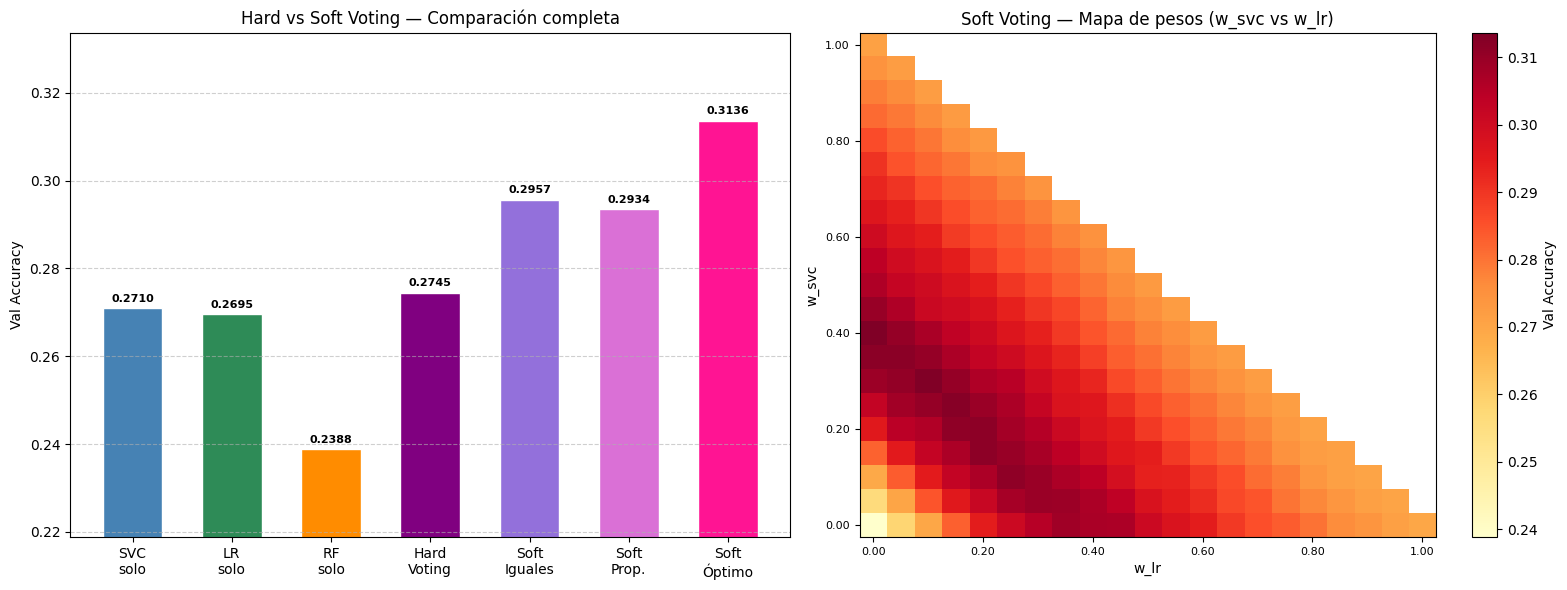


  Gráfica guardada en ensemble_hard_vs_soft.png

Reentrenando sobre el 100% del dataset con: Soft Voting óptimo...
  ✔ winner_model.csv generado (3490 filas)

¡Listo para subir a Kaggle!


In [5]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode


# ═════════════════════════════════════════════════════════════════════════════
# BLOQUE A — SÍMBOLOS Y EXPRESIONES REGULARES (para el RF)
# ═════════════════════════════════════════════════════════════════════════════

SIMBOLOS_FRECUENTES = [
    ',', '.', '-', '^', ':', ';', "'", '*', '(', '»',
    '/', '?', ')', '¿', '>', '«', '¡', '!', '|', '&',
    '¬', '<', '£', '"', '—', '$', '•', '\\', 'ſ', '[',
    '=', '\u2018', ']', '%', '■', '\u201c', '©', '}', '€', '{',
    '°', '„', '#', '+', '®', '\u201d', '\u2019', '_'
]
SIMBOLOS_MEDIEVALES = ['ꝛ', '§', '~', '⁊', 'ẽ', 'ũ', '⸗', 'õ', '™', 'ã', '♦']
TODOS_SIMBOLOS      = SIMBOLOS_FRECUENTES + SIMBOLOS_MEDIEVALES

def nombre_columna(simbolo):
    nombres = {
        ',': 'sim_coma', '.': 'sim_punto', '-': 'sim_guion', '^': 'sim_caret',
        ':': 'sim_dos_puntos', ';': 'sim_punto_coma', "'": 'sim_apostrofe', '*': 'sim_asterisco',
        '(': 'sim_paren_abrir', '»': 'sim_guillemet_der', '/': 'sim_barra', '?': 'sim_interrogacion',
        ')': 'sim_paren_cerrar', '¿': 'sim_interrogacion_es', '>': 'sim_mayor', '«': 'sim_guillemet_izq',
        '¡': 'sim_exclamacion_es', '!': 'sim_exclamacion', '|': 'sim_barra_vertical', '&': 'sim_ampersand',
        '¬': 'sim_silabeo', '<': 'sim_menor', '£': 'sim_libra', '"': 'sim_comilla_doble',
        '—': 'sim_raya', '$': 'sim_dolar', '•': 'sim_viñeta', '\\': 'sim_barra_inversa',
        'ſ': 'sim_s_larga', '[': 'sim_corchete_abrir', '=': 'sim_igual', '\u2018': 'sim_comilla_izq',
        ']': 'sim_corchete_cerrar', '%': 'sim_porcentaje', '■': 'sim_cuadrado', '\u201c': 'sim_comilla_doble_izq',
        '©': 'sim_copyright', '}': 'sim_llave_cerrar', '€': 'sim_euro', '{': 'sim_llave_abrir',
        '°': 'sim_grado', '„': 'sim_comilla_baja', '#': 'sim_almohadilla', '+': 'sim_mas',
        '®': 'sim_marca_reg', '\u201d': 'sim_comilla_doble_der', '\u2019': 'sim_comilla_der', '_': 'sim_guion_bajo',
        'ꝛ': 'sim_r_medieval', '§': 'sim_seccion', '~': 'sim_tilde', '⁊': 'sim_tironian_et',
        'ẽ': 'sim_e_tilde', 'ũ': 'sim_u_tilde', '⸗': 'sim_guion_doble', 'õ': 'sim_o_tilde',
        '™': 'sim_trademark', 'ã': 'sim_a_tilde', '♦': 'sim_rombo',
    }
    return nombres.get(simbolo, f'sim_{ord(simbolo)}')

COLUMNAS_SIMBOLOS = [nombre_columna(s) for s in TODOS_SIMBOLOS]

PALABRAS_ARCAICAS = re.compile(
    r'\b(?:efto|efta|eftos|eftas|dize|diziendo|dixo|hazer|fazer|dezir|cofa|'
    r'cofas|mifmo|mifma|afsi|affi|tambien|efpañ\w*|efcriv\w*|efcrib\w*|'
    r'vueftra|vueflra|vueftro|merced|feñor|feñora|ombre|fobre|fiempre|'
    r'defpues|aunque|donde|quando|porque|agora|anfi|afi|anſi)\b', re.IGNORECASE
)
PALABRAS_LATINAS = re.compile(
    r'\b\w+(?:ibus|orum|arum|onis|atis|ens|antis|um|us|is|ae)\b', re.IGNORECASE
)
NUMEROS_ROMANOS = re.compile(
    r'\b(M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3}))\b', re.IGNORECASE
)
ABREVIATURAS      = re.compile(r'\b[a-záéíóúüñ]{1,5}\.')
U_COMO_V          = re.compile(r'\bv[aeiouáéíóú]', re.IGNORECASE)
J_POR_X           = re.compile(
    r'\b(?:di[jx]o|ba[jx]o|me[jx]or|de[jx]ar|de[jx]ó|hi[jx]o|'
    r'mu[jx]er|tra[jx]|[jx]unto|[jx]ugar|[jx]uzgar|[jx]uicio)\b', re.IGNORECASE
)
MAYUS_MID_ORACION   = re.compile(r'(?<![.!?\n])\s+[A-ZÁÉÍÓÚÜÑ][a-záéíóúüñ]{2,}')
CONECTORES_MODERNOS = re.compile(
    r'\b(?:sin embargo|no obstante|es decir|por lo tanto|en consecuencia|'
    r'por consiguiente|a pesar de|dado que|puesto que|ya que|'
    r'en efecto|de hecho|por otro lado|en cambio|así pues)\b', re.IGNORECASE
)
VERBOS_ARCAICOS = re.compile(
    r'\b\w+(?:edes|ades|istes|ábades|íades|áredes|éredes|íredes)\b', re.IGNORECASE
)
CHARS_AISLADOS = re.compile(r'(?<!\w)\b([b-df-hj-np-tv-zB-DF-HJ-NP-TV-Z])\b(?!\w)')
F_INICIAL = re.compile(
    r'\b(?:fab\w+|faz\w+|fij\w+|ferm\w+|ferr\w+|fiel\w+|fil\w+|'
    r'fin\w+|fue\w+|fuy\w+|fall\w+|fal\w+|fam\w+|far\w+|fat\w+|'
    r'fech\w+|fend\w+|ferv\w+|fest\w+|fid\w+|fog\w+|folg\w+|fond\w+|'
    r'font\w+|forc\w+|forn\w+|forr\w+|foy\w+|fuert\w+|fug\w+)\b', re.IGNORECASE
)

FEATURE_NAMES = [
    'caracteres', 'palabras', 'simbolos', 'mayusculas', 'oraciones',
    'longitud_promedio_palabra', 'ratio_doble_espacio', 'palabras_arcaicas',
    'palabras_latinas', 'ratio_vocales_acentuadas', 'signos_es',
    'comillas_angulares', 'guiones', 'ruido_ocr',
    'entropia', 'diversidad_lexica', 'ratio_palabras_cortas',
    'espacios_por_palabra', 'saltos_por_palabra', 'tabs_por_palabra',
    'longitud_promedio_linea', 'cortes_guion_fin_linea', 'digitos_por_palabra',
    'ratio_numeros_romanos', 'ratio_abreviaturas', 'ratio_u_como_v', 'ratio_j_por_x',
    'ratio_mayus_mid', 'densidad_parrafos',
    'ratio_conectores_modernos', 'ratio_verbos_arcaicos',
    'ratio_e_vs_y', 'ratio_non_vs_no', 'ratio_art_la',
    'ratio_chars_aislados', 'ratio_grupos_consonantes',
    'ratio_hapax', 'ratio_palabras_largas', 'ratio_oraciones_largas',
    'ratio_tildes_sobre_mayusculas', 'ratio_q', 'ratio_f_inicial', 'ratio_i_vs_y',
] + COLUMNAS_SIMBOLOS

N_FEATURES_ESTILO = 43
assert len(FEATURE_NAMES) == N_FEATURES_ESTILO + len(TODOS_SIMBOLOS)


# ═════════════════════════════════════════════════════════════════════════════
# BLOQUE B — FUNCIONES DE LIMPIEZA Y EXTRACCIÓN
# ═════════════════════════════════════════════════════════════════════════════

def clean_svc(texto):
    if not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


def clean_lr(texto):
    if not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


def extraer_features_rf(texto):
    if not isinstance(texto, str) or len(texto) == 0:
        return [0] * (N_FEATURES_ESTILO + len(TODOS_SIMBOLOS))

    palabras_lista  = texto.split()
    n_palabras      = max(len(palabras_lista), 1)
    n_caracteres    = len(texto)
    n_espacios      = max(texto.count(' '), 1)
    n_saltos_linea  = texto.count('\n')
    total_letras    = max(len(re.findall(r'[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', texto)), 1)
    texto_lower     = texto.lower()

    mayusculas_count         = sum(1 for c in texto if c.isupper())
    vocales_acentuadas_count = len(re.findall(r'[áéíóúÁÉÍÓÚ]', texto))
    frecuencias              = Counter(texto)
    entropia = -sum((f / n_caracteres) * math.log2(f / n_caracteres)
                    for f in frecuencias.values()) if n_caracteres > 0 else 0
    freq_palabras   = Counter(palabras_lista)
    oraciones_lista = re.split(r'[.!?]+', texto)
    n_oraciones     = max(len(oraciones_lista), 1)
    conteo_e   = len(re.findall(r'\be\b', texto_lower))
    conteo_y   = len(re.findall(r'\by\b', texto_lower))
    conteo_non = len(re.findall(r'\bnon\b', texto_lower))
    conteo_no  = len(re.findall(r'\bno\b', texto_lower))
    conteo_i   = len(re.findall(r'\bi\b', texto_lower))

    features_estilo = [
        n_caracteres / n_palabras, n_palabras,
        len(re.findall(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', texto)) / n_palabras,
        mayusculas_count / n_palabras,
        max(len(re.findall(r'[.!?]+', texto)), 1) / n_palabras,
        np.mean([len(w) for w in palabras_lista]),
        len(re.findall(r' {2,}', texto)) / n_espacios,
        len(PALABRAS_ARCAICAS.findall(texto_lower)) / n_palabras,
        len(PALABRAS_LATINAS.findall(texto_lower)) / n_palabras,
        vocales_acentuadas_count / total_letras,
        len(re.findall(r'[¡¿]', texto)) / n_palabras,
        len(re.findall(r'[«»]', texto)) / n_palabras,
        len(re.findall(r'-', texto)) / n_palabras,
        len(re.findall(r'[\^*|&£><@#~\\`{}[\]=]', texto)) / n_palabras,
        entropia,
        len(set(palabras_lista)) / n_palabras,
        sum(1 for w in palabras_lista if len(w) <= 3) / n_palabras,
        texto.count(' ') / n_palabras,
        n_saltos_linea / n_palabras,
        texto.count('\t') / n_palabras,
        n_caracteres / (n_saltos_linea + 1),
        len(re.findall(r'-\s*\n', texto)) / n_palabras,
        sum(1 for c in texto if c.isdigit()) / n_palabras,
        len([m for m in NUMEROS_ROMANOS.findall(texto) if len(m[0]) >= 2]) / n_palabras,
        len(ABREVIATURAS.findall(texto_lower)) / n_palabras,
        len(U_COMO_V.findall(texto_lower)) / n_palabras,
        len(J_POR_X.findall(texto_lower)) / n_palabras,
        len(MAYUS_MID_ORACION.findall(texto)) / n_palabras,
        (len(re.findall(r'\n\s*\n', texto)) + 1) / n_palabras,
        len(CONECTORES_MODERNOS.findall(texto_lower)) / n_palabras,
        len(VERBOS_ARCAICOS.findall(texto_lower)) / n_palabras,
        conteo_e / (conteo_e + conteo_y + 1),
        conteo_non / (conteo_non + conteo_no + 1),
        len(re.findall(r'\bla\b', texto_lower)) / n_palabras,
        len(CHARS_AISLADOS.findall(texto)) / n_palabras,
        len(re.findall(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]{3,}', texto)) / n_palabras,
        sum(1 for f in freq_palabras.values() if f == 1) / n_palabras,
        sum(1 for w in palabras_lista if len(w) >= 8) / n_palabras,
        sum(1 for o in oraciones_lista if len(o.split()) > 30) / n_oraciones,
        vocales_acentuadas_count / max(mayusculas_count, 1),
        texto_lower.count('q') / total_letras,
        len(F_INICIAL.findall(texto_lower)) / n_palabras,
        conteo_i / (conteo_i + conteo_y + 1),
    ]
    return features_estilo + [texto.count(s) / n_palabras for s in TODOS_SIMBOLOS]


# ═════════════════════════════════════════════════════════════════════════════
# 1. CARGA Y PREPARACIÓN
# ═════════════════════════════════════════════════════════════════════════════
print("Cargando y preparando datos...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")

data["text_svc"]      = data["text"].apply(clean_svc)
data["text_lr"]       = data["text"].apply(clean_lr)
data_test["text_svc"] = data_test["text"].apply(clean_svc)
data_test["text_lr"]  = data_test["text"].apply(clean_lr)

print("  Extrayendo 102 features para el Random Forest...")
feat_train = np.array(data["text"].apply(extraer_features_rf).tolist(),      dtype=np.float32)
feat_test  = np.array(data_test["text"].apply(extraer_features_rf).tolist(), dtype=np.float32)

y = data["decade"]

X_svc_train, X_svc_val, y_train, y_val = train_test_split(
    data["text_svc"], y, test_size=0.2, random_state=42, stratify=y
)
X_lr_train, X_lr_val, _, _ = train_test_split(
    data["text_lr"], y, test_size=0.2, random_state=42, stratify=y
)
feat_tr, feat_val = train_test_split(
    feat_train, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train: {len(X_svc_train)} | Val: {len(X_svc_val)} | Clases: {y.nunique()}")


# ═════════════════════════════════════════════════════════════════════════════
# 2. VECTORIZACIÓN TF-IDF
# ═════════════════════════════════════════════════════════════════════════════
print("\nVectorizando con TF-IDF...")

tfidf_svc = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                             max_df=0.85, min_df=2, max_features=150000,
                             lowercase=False, sublinear_tf=True)
tfidf_lr  = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                             max_df=0.85, min_df=2, max_features=150000,
                             lowercase=False, sublinear_tf=True)

X_svc_tr_v  = tfidf_svc.fit_transform(X_svc_train)
X_svc_val_v = tfidf_svc.transform(X_svc_val)
X_lr_tr_v   = tfidf_lr.fit_transform(X_lr_train)
X_lr_val_v  = tfidf_lr.transform(X_lr_val)
print(f"  TF-IDF shape: {X_svc_tr_v.shape}")


# ═════════════════════════════════════════════════════════════════════════════
# 3. SELECCIÓN DE FEATURES PARA EL RF (umbral=0.0013)
# ═════════════════════════════════════════════════════════════════════════════
print("\nSeleccionando features para el RF (umbral=0.0013)...")

scaler_sel = StandardScaler()
rf_sel     = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                     min_samples_leaf=2, class_weight='balanced',
                                     random_state=42, n_jobs=-1)
rf_sel.fit(scaler_sel.fit_transform(feat_tr), y_train)

imp_df = pd.DataFrame({'feature': FEATURE_NAMES,
                        'importancia': rf_sel.feature_importances_}
                      ).sort_values('importancia', ascending=False)

features_retenidas = imp_df[imp_df['importancia'] >= 0.0013]['feature'].tolist()
indices_rf         = [FEATURE_NAMES.index(f) for f in features_retenidas]

feat_tr_r    = feat_tr[:,    indices_rf]
feat_val_r   = feat_val[:,   indices_rf]
feat_train_r = feat_train[:, indices_rf]
feat_test_r  = feat_test[:,  indices_rf]

scaler_rf  = StandardScaler()
X_rf_tr_s  = scaler_rf.fit_transform(feat_tr_r)
X_rf_val_s = scaler_rf.transform(feat_val_r)
print(f"  Features RF retenidas: {len(features_retenidas)}")


# ═════════════════════════════════════════════════════════════════════════════
# 4. ENTRENAMIENTO DE LOS 3 MODELOS BASE
#
#    NOTA sobre el soft voting:
#    Los 3 modelos deben devolver predict_proba() para poder promediar.
#    - LinearSVC no tiene predict_proba nativo → se calibra con CalibratedClassifierCV
#    - LogisticRegression → tiene predict_proba nativo
#    - RandomForest       → tiene predict_proba nativo
# ═════════════════════════════════════════════════════════════════════════════
print("\nEntrenando modelos base...")

# --- Modelo 1: LinearSVC calibrado (cv=3 para obtener probabilidades) ---
print("  [1/3] LinearSVC C=0.5 (cv=3 para calibrar probabilidades)...")
modelo_svc = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced',penalty='l2',
              random_state=42, max_iter=5000, dual=False),
    method='sigmoid', cv=3
)
modelo_svc.fit(X_svc_tr_v, y_train)
acc_svc = accuracy_score(y_val, modelo_svc.predict(X_svc_val_v))
print(f"      Val accuracy: {acc_svc:.4f}")

# --- Modelo 2: LogisticRegression (tiene predict_proba nativo) ---
print("  [2/3] LogisticRegression C=6...")
modelo_lr = LogisticRegression(
    C=6, class_weight='balanced',penalty='l2',
    solver='lbfgs', random_state=42, max_iter=5000
)
modelo_lr.fit(X_lr_tr_v, y_train)
acc_lr = accuracy_score(y_val, modelo_lr.predict(X_lr_val_v))
print(f"      Val accuracy: {acc_lr:.4f}")

# --- Modelo 3: Random Forest (tiene predict_proba nativo) ---
print("  [3/3] Random Forest n_estimators=700...")
modelo_rf = RandomForestClassifier(
    n_estimators=700, max_features='sqrt', min_samples_leaf=2,
    max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1
)
modelo_rf.fit(X_rf_tr_s, y_train)
acc_rf = accuracy_score(y_val, modelo_rf.predict(X_rf_val_s))
print(f"      Val accuracy: {acc_rf:.4f}")

print(f"\n  {'Modelo':<35} {'Val Accuracy':>12}")
print(f"  {'─'*48}")
print(f"  {'LinearSVC (C=0.5)':<35} {acc_svc:>12.4f}")
print(f"  {'LogisticRegression (C=6)':<35} {acc_lr:>12.4f}")
print(f"  {'Random Forest (700 árboles)':<35} {acc_rf:>12.4f}")


# ═════════════════════════════════════════════════════════════════════════════
# 5. HARD VOTING (mayoría simple de clases predichas)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*55)
print("HARD VOTING")
print("═"*55)

pred_svc = modelo_svc.predict(X_svc_val_v)
pred_lr  = modelo_lr.predict(X_lr_val_v)
pred_rf  = modelo_rf.predict(X_rf_val_s)

votos        = np.column_stack([pred_svc, pred_lr, pred_rf])
pred_hard, _ = mode(votos, axis=1)
pred_hard    = pred_hard.ravel()
acc_hard     = accuracy_score(y_val, pred_hard)

unanime    = np.sum((votos[:,0]==votos[:,1]) & (votos[:,1]==votos[:,2]))
mayoria    = np.sum(
    ((votos[:,0]==votos[:,1]) | (votos[:,1]==votos[:,2]) | (votos[:,0]==votos[:,2])) &
    ~((votos[:,0]==votos[:,1]) & (votos[:,1]==votos[:,2]))
)
desacuerdo = np.sum((votos[:,0]!=votos[:,1]) & (votos[:,1]!=votos[:,2]) & (votos[:,0]!=votos[:,2]))
total      = len(votos)

print(f"  Val Accuracy Hard Voting : {acc_hard:.4f}")
print(f"  Unanimidad (3/3) : {unanime:>5}  ({unanime/total*100:.1f}%)")
print(f"  Mayoría    (2/3) : {mayoria:>5}  ({mayoria/total*100:.1f}%)")
print(f"  Desacuerdo (0/3) : {desacuerdo:>5}  ({desacuerdo/total*100:.1f}%)")


# ═════════════════════════════════════════════════════════════════════════════
# 6. SOFT VOTING — exploración de pesos óptimos
#
#    prob_ensemble = w_svc * prob_svc + w_lr * prob_lr + w_rf * prob_rf
#    predicción    = argmax(prob_ensemble)
#
#    Se exploran pesos donde w_svc + w_lr + w_rf = 1
#    Los pesos se asignan en proporción al val accuracy individual
#    y también se busca la combinación óptima en una rejilla.
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*55)
print("SOFT VOTING")
print("═"*55)

# Probabilidades de cada modelo en validación
prob_svc = modelo_svc.predict_proba(X_svc_val_v)   # (n, 39)
prob_lr  = modelo_lr.predict_proba(X_lr_val_v)     # (n, 39)
prob_rf  = modelo_rf.predict_proba(X_rf_val_s)     # (n, 39)
clases   = modelo_svc.classes_

# --- 6a. Pesos iguales (1/3 cada uno) ---
prob_igual   = (prob_svc + prob_lr + prob_rf) / 3
pred_igual   = clases[np.argmax(prob_igual, axis=1)]
acc_igual    = accuracy_score(y_val, pred_igual)
print(f"\n  Pesos iguales (1/3, 1/3, 1/3)  : {acc_igual:.4f}")

# --- 6b. Pesos proporcionales al val accuracy individual ---
total_acc    = acc_svc + acc_lr + acc_rf
w_svc_prop   = acc_svc / total_acc
w_lr_prop    = acc_lr  / total_acc
w_rf_prop    = acc_rf  / total_acc
prob_prop    = w_svc_prop * prob_svc + w_lr_prop * prob_lr + w_rf_prop * prob_rf
pred_prop    = clases[np.argmax(prob_prop, axis=1)]
acc_prop     = accuracy_score(y_val, pred_prop)
print(f"  Pesos proporcionales al accuracy")
print(f"    w_svc={w_svc_prop:.3f} | w_lr={w_lr_prop:.3f} | w_rf={w_rf_prop:.3f}")
print(f"    Val Accuracy : {acc_prop:.4f}")

# --- 6c. Búsqueda de pesos óptimos en rejilla ---
print(f"\n  Buscando pesos óptimos (rejilla de paso 0.05)...")

mejor_acc_soft = 0
mejor_pesos    = (0.33, 0.33, 0.34)
historia_soft  = []

pesos_range = np.arange(0.0, 1.05, 0.05)

for w1 in pesos_range:
    for w2 in pesos_range:
        w3 = round(1.0 - w1 - w2, 4)
        if w3 < 0 or w3 > 1: continue

        prob_e = w1 * prob_svc + w2 * prob_lr + w3 * prob_rf
        acc    = accuracy_score(y_val, clases[np.argmax(prob_e, axis=1)])
        historia_soft.append((w1, w2, w3, acc))

        if acc > mejor_acc_soft:
            mejor_acc_soft = acc
            mejor_pesos    = (w1, w2, w3)

w_svc_opt, w_lr_opt, w_rf_opt = mejor_pesos
print(f"  Mejor combinación encontrada:")
print(f"    w_svc={w_svc_opt:.2f} | w_lr={w_lr_opt:.2f} | w_rf={w_rf_opt:.2f}")
print(f"    Val Accuracy : {mejor_acc_soft:.4f}")

# Predicción con pesos óptimos
prob_opt  = w_svc_opt * prob_svc + w_lr_opt * prob_lr + w_rf_opt * prob_rf
pred_soft = clases[np.argmax(prob_opt, axis=1)]
acc_soft  = accuracy_score(y_val, pred_soft)


# ═════════════════════════════════════════════════════════════════════════════
# 7. COMPARACIÓN FINAL HARD vs SOFT
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n  {'═'*55}")
print(f"  COMPARACIÓN HARD vs SOFT VOTING")
print(f"  {'═'*55}")
print(f"  LinearSVC solo              : {acc_svc:.4f}")
print(f"  LogisticRegression solo     : {acc_lr:.4f}")
print(f"  Random Forest solo          : {acc_rf:.4f}")
print(f"  {'─'*55}")
print(f"  Hard Voting                 : {acc_hard:.4f}")
print(f"  Soft Voting (pesos iguales) : {acc_igual:.4f}")
print(f"  Soft Voting (prop. acc)     : {acc_prop:.4f}")
print(f"  Soft Voting (óptimo)        : {acc_soft:.4f}  ← w=({w_svc_opt:.2f},{w_lr_opt:.2f},{w_rf_opt:.2f})")
print(f"  {'═'*55}")

ganador = max([
    ("Hard Voting",                 acc_hard),
    ("Soft Voting pesos iguales",   acc_igual),
    ("Soft Voting prop. accuracy",  acc_prop),
    ("Soft Voting óptimo",          acc_soft),
], key=lambda x: x[1])
print(f"\n  ✔ GANADOR: {ganador[0]} ({ganador[1]:.4f})")


# ═════════════════════════════════════════════════════════════════════════════
# 8. GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: comparación de todos los métodos
metodos = ['SVC\nsolo', 'LR\nsolo', 'RF\nsolo',
           'Hard\nVoting', 'Soft\nIguales', 'Soft\nProp.', 'Soft\nÓptimo']
accs    = [acc_svc, acc_lr, acc_rf, acc_hard, acc_igual, acc_prop, acc_soft]
colores = ['steelblue', 'seagreen', 'darkorange',
           'purple', 'mediumpurple', 'orchid', 'deeppink']

barras = axes[0].bar(metodos, accs, color=colores, edgecolor='white', width=0.6)
axes[0].set_ylim(min(accs) - 0.02, max(accs) + 0.02)
axes[0].set_title("Hard vs Soft Voting — Comparación completa", fontsize=12)
axes[0].set_ylabel("Val Accuracy")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for b, acc in zip(barras, accs):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: mapa de calor de pesos óptimos (w_svc vs w_lr)
hist_df = pd.DataFrame(historia_soft, columns=['w_svc', 'w_lr', 'w_rf', 'acc'])
pivot   = hist_df.pivot_table(index='w_svc', columns='w_lr', values='acc', aggfunc='max')
im      = axes[1].imshow(pivot.values, aspect='auto', cmap='YlOrRd', origin='lower')
axes[1].set_title("Soft Voting — Mapa de pesos (w_svc vs w_lr)", fontsize=12)
axes[1].set_xlabel("w_lr")
axes[1].set_ylabel("w_svc")
ticks = [f'{v:.2f}' for v in pivot.columns[::4]]
axes[1].set_xticks(range(0, len(pivot.columns), 4))
axes[1].set_xticklabels(ticks, fontsize=8)
axes[1].set_yticks(range(0, len(pivot.index), 4))
axes[1].set_yticklabels([f'{v:.2f}' for v in pivot.index[::4]], fontsize=8)
plt.colorbar(im, ax=axes[1], label='Val Accuracy')

plt.tight_layout()
plt.savefig("ensemble_hard_vs_soft.png", dpi=150)
plt.show()
print("\n  Gráfica guardada en ensemble_hard_vs_soft.png")


# ═════════════════════════════════════════════════════════════════════════════
# 9. MODELO FINAL — reentrenado sobre TODO el dataset con el mejor método
# ═════════════════════════════════════════════════════════════════════════════
print(f"\nReentrenando sobre el 100% del dataset con: {ganador[0]}...")

tfidf_svc_f = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_df=0.85, min_df=2, max_features=150000,
                               lowercase=False, sublinear_tf=True)
tfidf_lr_f  = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_df=0.85, min_df=2, max_features=150000,
                               lowercase=False, sublinear_tf=True)

X_full_svc = tfidf_svc_f.fit_transform(data["text_svc"])
X_full_lr  = tfidf_lr_f.fit_transform(data["text_lr"])

svc_f = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced', random_state=42,
              max_iter=5000, dual=False), method='sigmoid', cv=3)
svc_f.fit(X_full_svc, y)

lr_f = LogisticRegression(C=6, class_weight='balanced',
                           solver='lbfgs', random_state=42, max_iter=5000)
lr_f.fit(X_full_lr, y)

scaler_rf_f = StandardScaler()
X_full_rf_s = scaler_rf_f.fit_transform(feat_train_r)
X_test_rf_s = scaler_rf_f.transform(feat_test_r)

rf_f = RandomForestClassifier(
    n_estimators=700, max_features='sqrt', min_samples_leaf=2,
    max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1)
rf_f.fit(X_full_rf_s, y)

# Predicciones con el método ganador
prob_svc_test = svc_f.predict_proba(tfidf_svc_f.transform(data_test["text_svc"]))
prob_lr_test  = lr_f.predict_proba(tfidf_lr_f.transform(data_test["text_lr"]))
prob_rf_test  = rf_f.predict_proba(X_test_rf_s)

if "Hard" in ganador[0]:
    pred_svc_t = svc_f.predict(tfidf_svc_f.transform(data_test["text_svc"]))
    pred_lr_t  = lr_f.predict(tfidf_lr_f.transform(data_test["text_lr"]))
    pred_rf_t  = rf_f.predict(X_test_rf_s)
    votos_t    = np.column_stack([pred_svc_t, pred_lr_t, pred_rf_t])
    preds, _   = mode(votos_t, axis=1)
    predicciones = preds.ravel()
else:
    prob_final   = w_svc_opt * prob_svc_test + w_lr_opt * prob_lr_test + w_rf_opt * prob_rf_test
    predicciones = svc_f.classes_[np.argmax(prob_final, axis=1)]

pd.DataFrame({"id": data_test["id"], "answer": predicciones}).to_csv(
    "winner_model_3models.csv", index=False
)
print(f"  ✔ winner_model.csv generado ({len(data_test)} filas)")
print(f"\n¡Listo para subir a Kaggle!")

# ENSAMBLE DE LOS 3 MODELOS (HARD) - CLAUD

Cargando y preparando datos...
  Extrayendo 102 features para el Random Forest...
  Train: 25122 | Val: 6281 | Clases: 39

Vectorizando con TF-IDF...
  TF-IDF shape: (25122, 150000)

Seleccionando features para el RF (umbral=0.0013)...
  Features RF retenidas: 69

Entrenando modelos base...
  [1/3] LinearSVC C=0.5 (cv=3)...
      Val accuracy: 0.2710
  [2/3] LogisticRegression C=6...
      Val accuracy: 0.2692
  [3/3] Random Forest n_estimators=700 (puede tardar)...
      Val accuracy: 0.2388

  Modelo                              Val Accuracy
  ────────────────────────────────────────────────
  LinearSVC (C=0.5)                         0.2710
  LogisticRegression (C=6)                  0.2692
  Random Forest (700 árboles, 69 feat)       0.2388

Evaluando Hard Voting...

  ══════════════════════════════════════════════════
  RESULTADOS HARD VOTING
  ══════════════════════════════════════════════════
  LinearSVC (C=0.5)                : 0.2710
  LogisticRegression (C=6)         : 0.2692

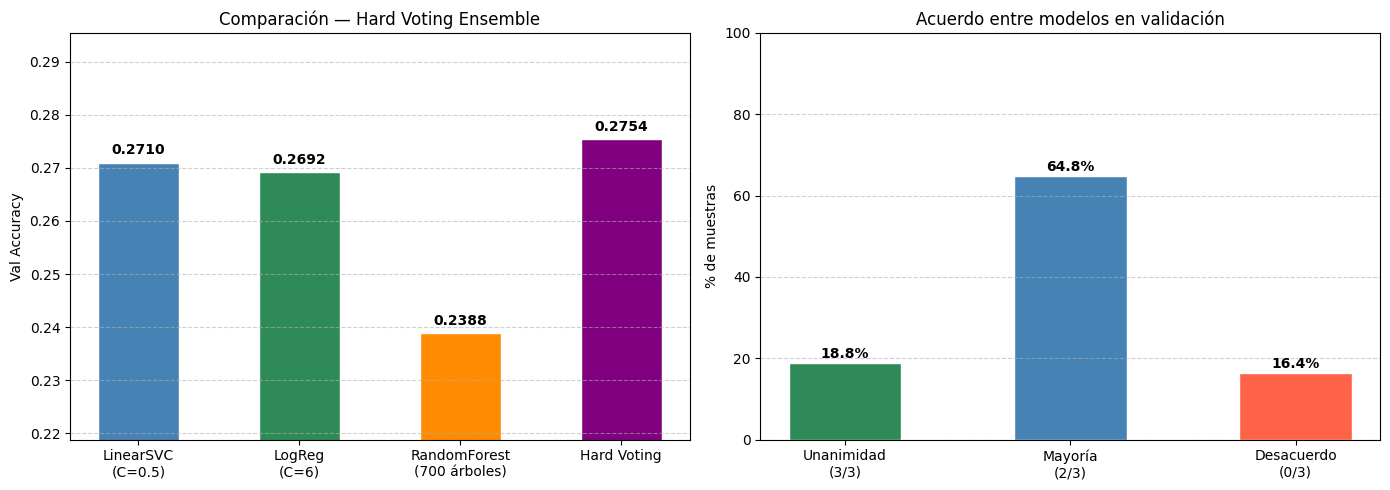


  Gráfica guardada en ensemble_hard_voting.png

Reentrenando sobre el 100% del dataset...


In [ ]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode


# ═════════════════════════════════════════════════════════════════════════════
# BLOQUE A — SÍMBOLOS Y EXPRESIONES REGULARES (para el RF)
# ═════════════════════════════════════════════════════════════════════════════

SIMBOLOS_FRECUENTES = [
    ',', '.', '-', '^', ':', ';', "'", '*', '(', '»',
    '/', '?', ')', '¿', '>', '«', '¡', '!', '|', '&',
    '¬', '<', '£', '"', '—', '$', '•', '\\', 'ſ', '[',
    '=', '\u2018', ']', '%', '■', '\u201c', '©', '}', '€', '{',
    '°', '„', '#', '+', '®', '\u201d', '\u2019', '_'
]
SIMBOLOS_MEDIEVALES = ['ꝛ', '§', '~', '⁊', 'ẽ', 'ũ', '⸗', 'õ', '™', 'ã', '♦']
TODOS_SIMBOLOS      = SIMBOLOS_FRECUENTES + SIMBOLOS_MEDIEVALES

def nombre_columna(simbolo):
    nombres = {
        ',': 'sim_coma', '.': 'sim_punto', '-': 'sim_guion', '^': 'sim_caret',
        ':': 'sim_dos_puntos', ';': 'sim_punto_coma', "'": 'sim_apostrofe', '*': 'sim_asterisco',
        '(': 'sim_paren_abrir', '»': 'sim_guillemet_der', '/': 'sim_barra', '?': 'sim_interrogacion',
        ')': 'sim_paren_cerrar', '¿': 'sim_interrogacion_es', '>': 'sim_mayor', '«': 'sim_guillemet_izq',
        '¡': 'sim_exclamacion_es', '!': 'sim_exclamacion', '|': 'sim_barra_vertical', '&': 'sim_ampersand',
        '¬': 'sim_silabeo', '<': 'sim_menor', '£': 'sim_libra', '"': 'sim_comilla_doble',
        '—': 'sim_raya', '$': 'sim_dolar', '•': 'sim_viñeta', '\\': 'sim_barra_inversa',
        'ſ': 'sim_s_larga', '[': 'sim_corchete_abrir', '=': 'sim_igual', '\u2018': 'sim_comilla_izq',
        ']': 'sim_corchete_cerrar', '%': 'sim_porcentaje', '■': 'sim_cuadrado', '\u201c': 'sim_comilla_doble_izq',
        '©': 'sim_copyright', '}': 'sim_llave_cerrar', '€': 'sim_euro', '{': 'sim_llave_abrir',
        '°': 'sim_grado', '„': 'sim_comilla_baja', '#': 'sim_almohadilla', '+': 'sim_mas',
        '®': 'sim_marca_reg', '\u201d': 'sim_comilla_doble_der', '\u2019': 'sim_comilla_der', '_': 'sim_guion_bajo',
        'ꝛ': 'sim_r_medieval', '§': 'sim_seccion', '~': 'sim_tilde', '⁊': 'sim_tironian_et',
        'ẽ': 'sim_e_tilde', 'ũ': 'sim_u_tilde', '⸗': 'sim_guion_doble', 'õ': 'sim_o_tilde',
        '™': 'sim_trademark', 'ã': 'sim_a_tilde', '♦': 'sim_rombo',
    }
    return nombres.get(simbolo, f'sim_{ord(simbolo)}')

COLUMNAS_SIMBOLOS = [nombre_columna(s) for s in TODOS_SIMBOLOS]

PALABRAS_ARCAICAS = re.compile(
    r'\b(?:efto|efta|eftos|eftas|dize|diziendo|dixo|hazer|fazer|dezir|cofa|'
    r'cofas|mifmo|mifma|afsi|affi|tambien|efpañ\w*|efcriv\w*|efcrib\w*|'
    r'vueftra|vueflra|vueftro|merced|feñor|feñora|ombre|fobre|fiempre|'
    r'defpues|aunque|donde|quando|porque|agora|anfi|afi|anſi)\b', re.IGNORECASE
)
PALABRAS_LATINAS = re.compile(
    r'\b\w+(?:ibus|orum|arum|onis|atis|ens|antis|um|us|is|ae)\b', re.IGNORECASE
)
NUMEROS_ROMANOS = re.compile(
    r'\b(M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3}))\b', re.IGNORECASE
)
ABREVIATURAS      = re.compile(r'\b[a-záéíóúüñ]{1,5}\.')
U_COMO_V          = re.compile(r'\bv[aeiouáéíóú]', re.IGNORECASE)
J_POR_X           = re.compile(
    r'\b(?:di[jx]o|ba[jx]o|me[jx]or|de[jx]ar|de[jx]ó|hi[jx]o|'
    r'mu[jx]er|tra[jx]|[jx]unto|[jx]ugar|[jx]uzgar|[jx]uicio)\b', re.IGNORECASE
)
MAYUS_MID_ORACION   = re.compile(r'(?<![.!?\n])\s+[A-ZÁÉÍÓÚÜÑ][a-záéíóúüñ]{2,}')
CONECTORES_MODERNOS = re.compile(
    r'\b(?:sin embargo|no obstante|es decir|por lo tanto|en consecuencia|'
    r'por consiguiente|a pesar de|dado que|puesto que|ya que|'
    r'en efecto|de hecho|por otro lado|en cambio|así pues)\b', re.IGNORECASE
)
VERBOS_ARCAICOS = re.compile(
    r'\b\w+(?:edes|ades|istes|ábades|íades|áredes|éredes|íredes)\b', re.IGNORECASE
)
CHARS_AISLADOS = re.compile(r'(?<!\w)\b([b-df-hj-np-tv-zB-DF-HJ-NP-TV-Z])\b(?!\w)')
F_INICIAL = re.compile(
    r'\b(?:fab\w+|faz\w+|fij\w+|ferm\w+|ferr\w+|fiel\w+|fil\w+|'
    r'fin\w+|fue\w+|fuy\w+|fall\w+|fal\w+|fam\w+|far\w+|fat\w+|'
    r'fech\w+|fend\w+|ferv\w+|fest\w+|fid\w+|fog\w+|folg\w+|fond\w+|'
    r'font\w+|forc\w+|forn\w+|forr\w+|foy\w+|fuert\w+|fug\w+)\b', re.IGNORECASE
)

FEATURE_NAMES = [
    'caracteres', 'palabras', 'simbolos', 'mayusculas', 'oraciones',
    'longitud_promedio_palabra', 'ratio_doble_espacio', 'palabras_arcaicas',
    'palabras_latinas', 'ratio_vocales_acentuadas', 'signos_es',
    'comillas_angulares', 'guiones', 'ruido_ocr',
    'entropia', 'diversidad_lexica', 'ratio_palabras_cortas',
    'espacios_por_palabra', 'saltos_por_palabra', 'tabs_por_palabra',
    'longitud_promedio_linea', 'cortes_guion_fin_linea', 'digitos_por_palabra',
    'ratio_numeros_romanos', 'ratio_abreviaturas', 'ratio_u_como_v', 'ratio_j_por_x',
    'ratio_mayus_mid', 'densidad_parrafos',
    'ratio_conectores_modernos', 'ratio_verbos_arcaicos',
    'ratio_e_vs_y', 'ratio_non_vs_no', 'ratio_art_la',
    'ratio_chars_aislados', 'ratio_grupos_consonantes',
    'ratio_hapax', 'ratio_palabras_largas', 'ratio_oraciones_largas',
    'ratio_tildes_sobre_mayusculas', 'ratio_q', 'ratio_f_inicial', 'ratio_i_vs_y',
] + COLUMNAS_SIMBOLOS

N_FEATURES_ESTILO = 43
assert len(FEATURE_NAMES) == N_FEATURES_ESTILO + len(TODOS_SIMBOLOS)


# ═════════════════════════════════════════════════════════════════════════════
# BLOQUE B — FUNCIONES DE LIMPIEZA Y EXTRACCIÓN
# ═════════════════════════════════════════════════════════════════════════════

def clean_svc(texto):
    """SVC: reemplaza ñ→n (limpieza original del modelo ganador)."""
    if not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = texto.replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


def clean_lr(texto):
    """LR: conserva ñ (limpieza original del modelo ganador)."""
    if not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


def extraer_features_rf(texto):
    """102 features para el RF (texto crudo — sin limpiar)."""
    if not isinstance(texto, str) or len(texto) == 0:
        return [0] * (N_FEATURES_ESTILO + len(TODOS_SIMBOLOS))

    palabras_lista  = texto.split()
    n_palabras      = max(len(palabras_lista), 1)
    n_caracteres    = len(texto)
    n_espacios      = max(texto.count(' '), 1)
    n_saltos_linea  = texto.count('\n')
    total_letras    = max(len(re.findall(r'[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', texto)), 1)
    texto_lower     = texto.lower()

    mayusculas_count         = sum(1 for c in texto if c.isupper())
    vocales_acentuadas_count = len(re.findall(r'[áéíóúÁÉÍÓÚ]', texto))
    frecuencias              = Counter(texto)
    entropia = -sum((f / n_caracteres) * math.log2(f / n_caracteres)
                    for f in frecuencias.values()) if n_caracteres > 0 else 0
    freq_palabras   = Counter(palabras_lista)
    oraciones_lista = re.split(r'[.!?]+', texto)
    n_oraciones     = max(len(oraciones_lista), 1)
    conteo_e   = len(re.findall(r'\be\b', texto_lower))
    conteo_y   = len(re.findall(r'\by\b', texto_lower))
    conteo_non = len(re.findall(r'\bnon\b', texto_lower))
    conteo_no  = len(re.findall(r'\bno\b', texto_lower))
    conteo_i   = len(re.findall(r'\bi\b', texto_lower))

    features_estilo = [
        n_caracteres / n_palabras,
        n_palabras,
        len(re.findall(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', texto)) / n_palabras,
        mayusculas_count / n_palabras,
        max(len(re.findall(r'[.!?]+', texto)), 1) / n_palabras,
        np.mean([len(w) for w in palabras_lista]),
        len(re.findall(r' {2,}', texto)) / n_espacios,
        len(PALABRAS_ARCAICAS.findall(texto_lower)) / n_palabras,
        len(PALABRAS_LATINAS.findall(texto_lower)) / n_palabras,
        vocales_acentuadas_count / total_letras,
        len(re.findall(r'[¡¿]', texto)) / n_palabras,
        len(re.findall(r'[«»]', texto)) / n_palabras,
        len(re.findall(r'-', texto)) / n_palabras,
        len(re.findall(r'[\^*|&£><@#~\\`{}[\]=]', texto)) / n_palabras,
        entropia,
        len(set(palabras_lista)) / n_palabras,
        sum(1 for w in palabras_lista if len(w) <= 3) / n_palabras,
        texto.count(' ') / n_palabras,
        n_saltos_linea / n_palabras,
        texto.count('\t') / n_palabras,
        n_caracteres / (n_saltos_linea + 1),
        len(re.findall(r'-\s*\n', texto)) / n_palabras,
        sum(1 for c in texto if c.isdigit()) / n_palabras,
        len([m for m in NUMEROS_ROMANOS.findall(texto) if len(m[0]) >= 2]) / n_palabras,
        len(ABREVIATURAS.findall(texto_lower)) / n_palabras,
        len(U_COMO_V.findall(texto_lower)) / n_palabras,
        len(J_POR_X.findall(texto_lower)) / n_palabras,
        len(MAYUS_MID_ORACION.findall(texto)) / n_palabras,
        (len(re.findall(r'\n\s*\n', texto)) + 1) / n_palabras,
        len(CONECTORES_MODERNOS.findall(texto_lower)) / n_palabras,
        len(VERBOS_ARCAICOS.findall(texto_lower)) / n_palabras,
        conteo_e / (conteo_e + conteo_y + 1),
        conteo_non / (conteo_non + conteo_no + 1),
        len(re.findall(r'\bla\b', texto_lower)) / n_palabras,
        len(CHARS_AISLADOS.findall(texto)) / n_palabras,
        len(re.findall(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]{3,}', texto)) / n_palabras,
        sum(1 for f in freq_palabras.values() if f == 1) / n_palabras,
        sum(1 for w in palabras_lista if len(w) >= 8) / n_palabras,
        sum(1 for o in oraciones_lista if len(o.split()) > 30) / n_oraciones,
        vocales_acentuadas_count / max(mayusculas_count, 1),
        texto_lower.count('q') / total_letras,
        len(F_INICIAL.findall(texto_lower)) / n_palabras,
        conteo_i / (conteo_i + conteo_y + 1),
    ]

    ratios_simbolos = [texto.count(s) / n_palabras for s in TODOS_SIMBOLOS]
    return features_estilo + ratios_simbolos


# ═════════════════════════════════════════════════════════════════════════════
# 1. CARGA Y PREPARACIÓN
# ═════════════════════════════════════════════════════════════════════════════
print("Cargando y preparando datos...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")

# Textos limpios para SVC y LR
data["text_svc"]      = data["text"].apply(clean_svc)
data["text_lr"]       = data["text"].apply(clean_lr)
data_test["text_svc"] = data_test["text"].apply(clean_svc)
data_test["text_lr"]  = data_test["text"].apply(clean_lr)

# Features manuales para RF (texto crudo)
print("  Extrayendo 102 features para el Random Forest...")
feat_train = np.array(data["text"].apply(extraer_features_rf).tolist(),      dtype=np.float32)
feat_test  = np.array(data_test["text"].apply(extraer_features_rf).tolist(), dtype=np.float32)

y = data["decade"]

# Un único split → mismas muestras en val para los 3
X_svc_train, X_svc_val, y_train, y_val = train_test_split(
    data["text_svc"], y, test_size=0.2, random_state=42, stratify=y
)
X_lr_train, X_lr_val, _, _ = train_test_split(
    data["text_lr"], y, test_size=0.2, random_state=42, stratify=y
)
feat_tr, feat_val = train_test_split(
    feat_train, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train: {len(X_svc_train)} | Val: {len(X_svc_val)} | Clases: {y.nunique()}")


# ═════════════════════════════════════════════════════════════════════════════
# 2. VECTORIZACIÓN TF-IDF (SVC y LR)
#    Parámetros exactos de los modelos ganadores
# ═════════════════════════════════════════════════════════════════════════════
print("\nVectorizando con TF-IDF...")

tfidf_svc = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_df=0.85, min_df=2, max_features=150000,
    lowercase=False, sublinear_tf=True
)
tfidf_lr = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_df=0.85, min_df=2, max_features=150000,
    lowercase=False, sublinear_tf=True
)

X_svc_tr_v  = tfidf_svc.fit_transform(X_svc_train)
X_svc_val_v = tfidf_svc.transform(X_svc_val)
X_lr_tr_v   = tfidf_lr.fit_transform(X_lr_train)
X_lr_val_v  = tfidf_lr.transform(X_lr_val)
print(f"  TF-IDF shape: {X_svc_tr_v.shape}")


# ═════════════════════════════════════════════════════════════════════════════
# 3. SELECCIÓN DE FEATURES PARA EL RF
#    Proceso exacto del modelo ganador:
#    → RF inicial con n_estimators=500 para obtener Gini
#    → corte umbral=0.0013 → ~69 features retenidas
# ═════════════════════════════════════════════════════════════════════════════
print("\nSeleccionando features para el RF (umbral=0.0013)...")

scaler_sel = StandardScaler()
X_sel_s    = scaler_sel.fit_transform(feat_tr)
rf_sel     = RandomForestClassifier(
    n_estimators=500, max_features='sqrt', min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_sel.fit(X_sel_s, y_train)

imp_df = pd.DataFrame({'feature': FEATURE_NAMES,
                        'importancia': rf_sel.feature_importances_}
                      ).sort_values('importancia', ascending=False)

UMBRAL             = 0.0013
features_retenidas = imp_df[imp_df['importancia'] >= UMBRAL]['feature'].tolist()
indices_rf         = [FEATURE_NAMES.index(f) for f in features_retenidas]

feat_tr_r      = feat_tr[:,    indices_rf]
feat_val_r     = feat_val[:,   indices_rf]
feat_train_r   = feat_train[:, indices_rf]   # para reentrenamiento final
feat_test_r    = feat_test[:,  indices_rf]

scaler_rf  = StandardScaler()
X_rf_tr_s  = scaler_rf.fit_transform(feat_tr_r)
X_rf_val_s = scaler_rf.transform(feat_val_r)
print(f"  Features RF retenidas: {len(features_retenidas)}")


# ═════════════════════════════════════════════════════════════════════════════
# 4. ENTRENAMIENTO DE LOS 3 MODELOS BASE
# ═════════════════════════════════════════════════════════════════════════════
print("\nEntrenando modelos base...")

# --- Modelo 1: LinearSVC (C=0.5) ---
print("  [1/3] LinearSVC C=0.5 (cv=3)...")
modelo_svc = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced',
              random_state=42, max_iter=5000, dual=False),
    method='sigmoid', cv=3
)
modelo_svc.fit(X_svc_tr_v, y_train)
acc_svc = accuracy_score(y_val, modelo_svc.predict(X_svc_val_v))
print(f"      Val accuracy: {acc_svc:.4f}")

# --- Modelo 2: LogisticRegression (C=6) ---
print("  [2/3] LogisticRegression C=6...")
modelo_lr = LogisticRegression(
    C=6, class_weight='balanced',
    solver='lbfgs', random_state=42, max_iter=5000
)
modelo_lr.fit(X_lr_tr_v, y_train)
acc_lr = accuracy_score(y_val, modelo_lr.predict(X_lr_val_v))
print(f"      Val accuracy: {acc_lr:.4f}")

# --- Modelo 3: Random Forest (n_estimators=700, el ganador) ---
print("  [3/3] Random Forest n_estimators=700 (puede tardar)...")
modelo_rf = RandomForestClassifier(
    n_estimators=700, max_features='sqrt', min_samples_leaf=2,
    max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1
)
modelo_rf.fit(X_rf_tr_s, y_train)
acc_rf = accuracy_score(y_val, modelo_rf.predict(X_rf_val_s))
print(f"      Val accuracy: {acc_rf:.4f}")

print(f"\n  {'Modelo':<35} {'Val Accuracy':>12}")
print(f"  {'─'*48}")
print(f"  {'LinearSVC (C=0.5)':<35} {acc_svc:>12.4f}")
print(f"  {'LogisticRegression (C=6)':<35} {acc_lr:>12.4f}")
print(f"  {'Random Forest (700 árboles, 69 feat)':<35} {acc_rf:>12.4f}")


# ═════════════════════════════════════════════════════════════════════════════
# 5. HARD VOTING
# ═════════════════════════════════════════════════════════════════════════════
print("\nEvaluando Hard Voting...")

pred_svc = modelo_svc.predict(X_svc_val_v)
pred_lr  = modelo_lr.predict(X_lr_val_v)
pred_rf  = modelo_rf.predict(X_rf_val_s)

votos        = np.column_stack([pred_svc, pred_lr, pred_rf])
pred_hard, _ = mode(votos, axis=1)
pred_hard    = pred_hard.ravel()
acc_hard     = accuracy_score(y_val, pred_hard)

unanime    = np.sum((votos[:,0]==votos[:,1]) & (votos[:,1]==votos[:,2]))
mayoria    = np.sum(
    ((votos[:,0]==votos[:,1]) | (votos[:,1]==votos[:,2]) | (votos[:,0]==votos[:,2])) &
    ~((votos[:,0]==votos[:,1]) & (votos[:,1]==votos[:,2]))
)
desacuerdo = np.sum((votos[:,0]!=votos[:,1]) & (votos[:,1]!=votos[:,2]) & (votos[:,0]!=votos[:,2]))
total      = len(votos)

mejor_ind = max(acc_svc, acc_lr, acc_rf)
mejora    = "✔ MEJORA" if acc_hard > mejor_ind else "≈ similar al mejor individual"

print(f"\n  {'═'*50}")
print(f"  RESULTADOS HARD VOTING")
print(f"  {'═'*50}")
print(f"  LinearSVC (C=0.5)                : {acc_svc:.4f}")
print(f"  LogisticRegression (C=6)         : {acc_lr:.4f}")
print(f"  Random Forest (700, 69 features) : {acc_rf:.4f}")
print(f"  {'─'*50}")
print(f"  Ensamble Hard Voting             : {acc_hard:.4f}  ← {mejora}")
print(f"  {'═'*50}")
print(f"\n  Análisis de acuerdos ({total} muestras):")
print(f"  Unanimidad (3/3) : {unanime:>5}  ({unanime/total*100:.1f}%)")
print(f"  Mayoría    (2/3) : {mayoria:>5}  ({mayoria/total*100:.1f}%)")
print(f"  Desacuerdo (0/3) : {desacuerdo:>5}  ({desacuerdo/total*100:.1f}%)")


# ═════════════════════════════════════════════════════════════════════════════
# 6. GRÁFICA
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos    = ['LinearSVC\n(C=0.5)', 'LogReg\n(C=6)', 'RandomForest\n(700 árboles)', 'Hard Voting']
accuracies = [acc_svc, acc_lr, acc_rf, acc_hard]
colores    = ['steelblue', 'seagreen', 'darkorange', 'purple']

barras = axes[0].bar(modelos, accuracies, color=colores, width=0.5, edgecolor='white')
axes[0].set_ylim(min(accuracies) - 0.02, max(accuracies) + 0.02)
axes[0].set_title("Comparación — Hard Voting Ensemble", fontsize=12)
axes[0].set_ylabel("Val Accuracy")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for b, acc in zip(barras, accuracies):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

etiq  = ['Unanimidad\n(3/3)', 'Mayoría\n(2/3)', 'Desacuerdo\n(0/3)']
vals  = [unanime/total*100, mayoria/total*100, desacuerdo/total*100]
cols2 = ['seagreen', 'steelblue', 'tomato']
barras2 = axes[1].bar(etiq, vals, color=cols2, width=0.5, edgecolor='white')
axes[1].set_title("Acuerdo entre modelos en validación", fontsize=12)
axes[1].set_ylabel("% de muestras")
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for b, v in zip(barras2, vals):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("ensemble_hard_voting.png", dpi=150)
plt.show()
print("\n  Gráfica guardada en ensemble_hard_voting.png")


# ═════════════════════════════════════════════════════════════════════════════
# 7. MODELO FINAL — reentrenado sobre TODO el dataset
# ═════════════════════════════════════════════════════════════════════════════
print("\nReentrenando sobre el 100% del dataset...")

# TF-IDF finales
tfidf_svc_f = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_df=0.85, min_df=2, max_features=150000,
    lowercase=False, sublinear_tf=True
)
tfidf_lr_f = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_df=0.85, min_df=2, max_features=150000,
    lowercase=False, sublinear_tf=True
)

X_full_svc = tfidf_svc_f.fit_transform(data["text_svc"])
X_full_lr  = tfidf_lr_f.fit_transform(data["text_lr"])

svc_f = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced', random_state=42,
              max_iter=5000, dual=False),
    method='sigmoid', cv=3
)
svc_f.fit(X_full_svc, y)

lr_f = LogisticRegression(C=6, class_weight='balanced',
                           solver='lbfgs', random_state=42, max_iter=5000)
lr_f.fit(X_full_lr, y)

scaler_rf_f = StandardScaler()
X_full_rf_s = scaler_rf_f.fit_transform(feat_train_r)
X_test_rf_s = scaler_rf_f.transform(feat_test_r)

rf_f = RandomForestClassifier(
    n_estimators=700, max_features='sqrt', min_samples_leaf=2,
    max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_f.fit(X_full_rf_s, y)

print("  Modelos finales entrenados.")


# ═════════════════════════════════════════════════════════════════════════════
# 8. PREDICCIONES Y ARCHIVO PARA KAGGLE
# ═════════════════════════════════════════════════════════════════════════════
print("\nGenerando predicciones para Kaggle...")

pred_svc_test = svc_f.predict(tfidf_svc_f.transform(data_test["text_svc"]))
pred_lr_test  = lr_f.predict(tfidf_lr_f.transform(data_test["text_lr"]))
pred_rf_test  = rf_f.predict(X_test_rf_s)

votos_test       = np.column_stack([pred_svc_test, pred_lr_test, pred_rf_test])
predicciones, _  = mode(votos_test, axis=1)
predicciones     = predicciones.ravel()

submission = pd.DataFrame({"id": data_test["id"], "answer": predicciones})
submission.to_csv("winner_model.csv", index=False)

print(f"  ✔ winner_model.csv generado ({len(submission)} filas)")
print(f"\n  {'═'*50}")
print(f"  RESUMEN FINAL")
print(f"  {'═'*50}")
print(f"  LinearSVC (C=0.5)           : {acc_svc:.4f}  → Kaggle ~0.30276")
print(f"  LogisticRegression (C=6)    : {acc_lr:.4f}  → Kaggle ~0.29608")
print(f"  Random Forest (700 árboles) : {acc_rf:.4f}")
print(f"  Hard Voting Ensemble        : {acc_hard:.4f}")
print(f"  {'═'*50}")
print(f"\n¡Listo para subir a Kaggle!")

Cargando y preparando datos...
  Extrayendo 102 features para el Random Forest...
  Train: 25122 | Val: 6281

Vectorizando con TF-IDF...
  TF-IDF shape: (25122, 150000)

Seleccionando features para el RF (umbral=0.0013)...
  Features RF retenidas: 69

Entrenando modelos...
  [1/2] LinearSVC C=0.5 (calibrado con cv=3)...
      Val accuracy: 0.2710
  [2/2] Random Forest n_estimators=700...
      Val accuracy: 0.2388

Buscando peso óptimo (paso 0.01)...

   w_svc |   w_rf |  Val Acc
  ────────────────────────────
    0.00 |   1.00 |   0.2388
    0.01 |   0.99 |   0.2426
    0.02 |   0.98 |   0.2463
    0.03 |   0.97 |   0.2495
    0.04 |   0.96 |   0.2530
    0.05 |   0.95 |   0.2562
    0.06 |   0.94 |   0.2587
    0.07 |   0.93 |   0.2622
    0.08 |   0.92 |   0.2646
    0.09 |   0.91 |   0.2676
    0.10 |   0.90 |   0.2691
    0.11 |   0.89 |   0.2703
    0.12 |   0.88 |   0.2740
    0.13 |   0.87 |   0.2759
    0.14 |   0.86 |   0.2794
    0.15 |   0.85 |   0.2824
    0.16 |   0.84 | 

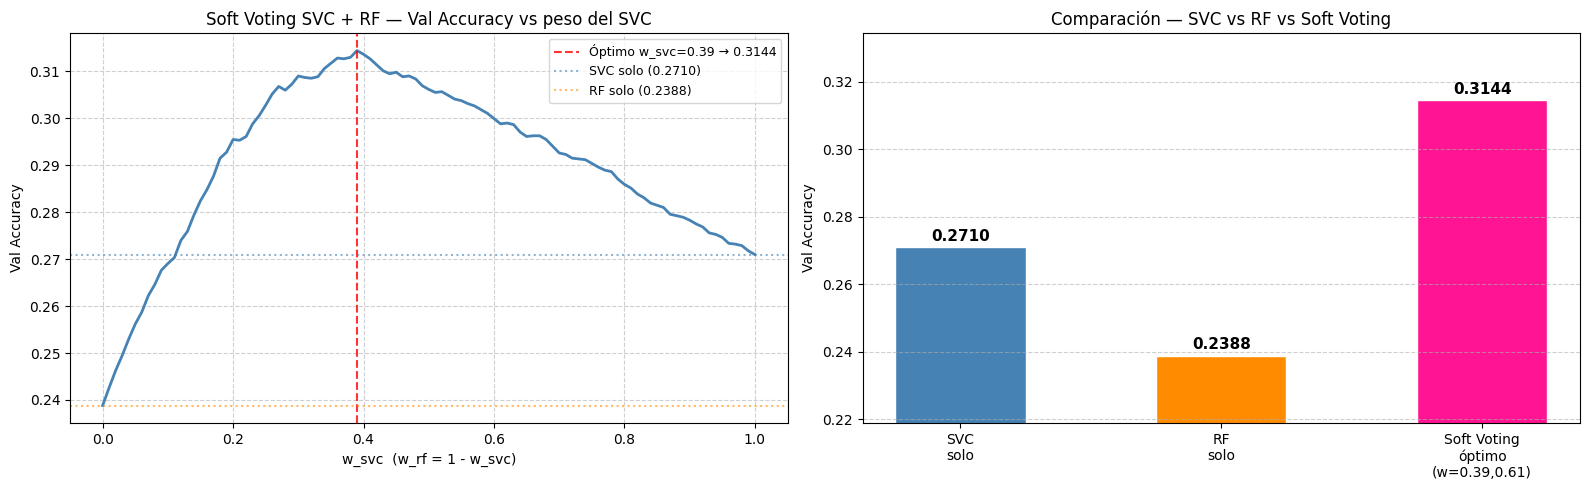


  Gráfica guardada en soft_voting_svc_rf.png

Reentrenando sobre el 100% del dataset...
  ✔ winner_model.csv generado (3490 filas)

  ═════════════════════════════════════════════
  RESUMEN FINAL
  ═════════════════════════════════════════════
  SVC solo           : 0.2710
  RF solo            : 0.2388
  Soft Voting óptimo : 0.3144  (w_svc=0.39, w_rf=0.61)
  Mejora vs SVC solo : +0.0435
  ═════════════════════════════════════════════

¡Listo para subir a Kaggle!


In [3]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler


# ═════════════════════════════════════════════════════════════════════════════
# BLOQUE A — SÍMBOLOS Y EXPRESIONES REGULARES (para el RF)
# ═════════════════════════════════════════════════════════════════════════════

SIMBOLOS_FRECUENTES = [
    ',', '.', '-', '^', ':', ';', "'", '*', '(', '»',
    '/', '?', ')', '¿', '>', '«', '¡', '!', '|', '&',
    '¬', '<', '£', '"', '—', '$', '•', '\\', 'ſ', '[',
    '=', '\u2018', ']', '%', '■', '\u201c', '©', '}', '€', '{',
    '°', '„', '#', '+', '®', '\u201d', '\u2019', '_'
]
SIMBOLOS_MEDIEVALES = ['ꝛ', '§', '~', '⁊', 'ẽ', 'ũ', '⸗', 'õ', '™', 'ã', '♦']
TODOS_SIMBOLOS      = SIMBOLOS_FRECUENTES + SIMBOLOS_MEDIEVALES

def nombre_columna(simbolo):
    nombres = {
        ',': 'sim_coma', '.': 'sim_punto', '-': 'sim_guion', '^': 'sim_caret',
        ':': 'sim_dos_puntos', ';': 'sim_punto_coma', "'": 'sim_apostrofe', '*': 'sim_asterisco',
        '(': 'sim_paren_abrir', '»': 'sim_guillemet_der', '/': 'sim_barra', '?': 'sim_interrogacion',
        ')': 'sim_paren_cerrar', '¿': 'sim_interrogacion_es', '>': 'sim_mayor', '«': 'sim_guillemet_izq',
        '¡': 'sim_exclamacion_es', '!': 'sim_exclamacion', '|': 'sim_barra_vertical', '&': 'sim_ampersand',
        '¬': 'sim_silabeo', '<': 'sim_menor', '£': 'sim_libra', '"': 'sim_comilla_doble',
        '—': 'sim_raya', '$': 'sim_dolar', '•': 'sim_viñeta', '\\': 'sim_barra_inversa',
        'ſ': 'sim_s_larga', '[': 'sim_corchete_abrir', '=': 'sim_igual', '\u2018': 'sim_comilla_izq',
        ']': 'sim_corchete_cerrar', '%': 'sim_porcentaje', '■': 'sim_cuadrado', '\u201c': 'sim_comilla_doble_izq',
        '©': 'sim_copyright', '}': 'sim_llave_cerrar', '€': 'sim_euro', '{': 'sim_llave_abrir',
        '°': 'sim_grado', '„': 'sim_comilla_baja', '#': 'sim_almohadilla', '+': 'sim_mas',
        '®': 'sim_marca_reg', '\u201d': 'sim_comilla_doble_der', '\u2019': 'sim_comilla_der', '_': 'sim_guion_bajo',
        'ꝛ': 'sim_r_medieval', '§': 'sim_seccion', '~': 'sim_tilde', '⁊': 'sim_tironian_et',
        'ẽ': 'sim_e_tilde', 'ũ': 'sim_u_tilde', '⸗': 'sim_guion_doble', 'õ': 'sim_o_tilde',
        '™': 'sim_trademark', 'ã': 'sim_a_tilde', '♦': 'sim_rombo',
    }
    return nombres.get(simbolo, f'sim_{ord(simbolo)}')

COLUMNAS_SIMBOLOS = [nombre_columna(s) for s in TODOS_SIMBOLOS]

PALABRAS_ARCAICAS = re.compile(
    r'\b(?:efto|efta|eftos|eftas|dize|diziendo|dixo|hazer|fazer|dezir|cofa|'
    r'cofas|mifmo|mifma|afsi|affi|tambien|efpañ\w*|efcriv\w*|efcrib\w*|'
    r'vueftra|vueflra|vueftro|merced|feñor|feñora|ombre|fobre|fiempre|'
    r'defpues|aunque|donde|quando|porque|agora|anfi|afi|anſi)\b', re.IGNORECASE
)
PALABRAS_LATINAS = re.compile(
    r'\b\w+(?:ibus|orum|arum|onis|atis|ens|antis|um|us|is|ae)\b', re.IGNORECASE
)
NUMEROS_ROMANOS = re.compile(
    r'\b(M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3}))\b', re.IGNORECASE
)
ABREVIATURAS      = re.compile(r'\b[a-záéíóúüñ]{1,5}\.')
U_COMO_V          = re.compile(r'\bv[aeiouáéíóú]', re.IGNORECASE)
J_POR_X           = re.compile(
    r'\b(?:di[jx]o|ba[jx]o|me[jx]or|de[jx]ar|de[jx]ó|hi[jx]o|'
    r'mu[jx]er|tra[jx]|[jx]unto|[jx]ugar|[jx]uzgar|[jx]uicio)\b', re.IGNORECASE
)
MAYUS_MID_ORACION   = re.compile(r'(?<![.!?\n])\s+[A-ZÁÉÍÓÚÜÑ][a-záéíóúüñ]{2,}')
CONECTORES_MODERNOS = re.compile(
    r'\b(?:sin embargo|no obstante|es decir|por lo tanto|en consecuencia|'
    r'por consiguiente|a pesar de|dado que|puesto que|ya que|'
    r'en efecto|de hecho|por otro lado|en cambio|así pues)\b', re.IGNORECASE
)
VERBOS_ARCAICOS = re.compile(
    r'\b\w+(?:edes|ades|istes|ábades|íades|áredes|éredes|íredes)\b', re.IGNORECASE
)
CHARS_AISLADOS = re.compile(r'(?<!\w)\b([b-df-hj-np-tv-zB-DF-HJ-NP-TV-Z])\b(?!\w)')
F_INICIAL = re.compile(
    r'\b(?:fab\w+|faz\w+|fij\w+|ferm\w+|ferr\w+|fiel\w+|fil\w+|'
    r'fin\w+|fue\w+|fuy\w+|fall\w+|fal\w+|fam\w+|far\w+|fat\w+|'
    r'fech\w+|fend\w+|ferv\w+|fest\w+|fid\w+|fog\w+|folg\w+|fond\w+|'
    r'font\w+|forc\w+|forn\w+|forr\w+|foy\w+|fuert\w+|fug\w+)\b', re.IGNORECASE
)

FEATURE_NAMES = [
    'caracteres', 'palabras', 'simbolos', 'mayusculas', 'oraciones',
    'longitud_promedio_palabra', 'ratio_doble_espacio', 'palabras_arcaicas',
    'palabras_latinas', 'ratio_vocales_acentuadas', 'signos_es',
    'comillas_angulares', 'guiones', 'ruido_ocr',
    'entropia', 'diversidad_lexica', 'ratio_palabras_cortas',
    'espacios_por_palabra', 'saltos_por_palabra', 'tabs_por_palabra',
    'longitud_promedio_linea', 'cortes_guion_fin_linea', 'digitos_por_palabra',
    'ratio_numeros_romanos', 'ratio_abreviaturas', 'ratio_u_como_v', 'ratio_j_por_x',
    'ratio_mayus_mid', 'densidad_parrafos',
    'ratio_conectores_modernos', 'ratio_verbos_arcaicos',
    'ratio_e_vs_y', 'ratio_non_vs_no', 'ratio_art_la',
    'ratio_chars_aislados', 'ratio_grupos_consonantes',
    'ratio_hapax', 'ratio_palabras_largas', 'ratio_oraciones_largas',
    'ratio_tildes_sobre_mayusculas', 'ratio_q', 'ratio_f_inicial', 'ratio_i_vs_y',
] + COLUMNAS_SIMBOLOS

N_FEATURES_ESTILO = 43
assert len(FEATURE_NAMES) == N_FEATURES_ESTILO + len(TODOS_SIMBOLOS)


# ═════════════════════════════════════════════════════════════════════════════
# BLOQUE B — FUNCIONES
# ═════════════════════════════════════════════════════════════════════════════

def clean_svc(texto):
    """SVC: reemplaza ñ→n."""
    if not isinstance(texto, str): return ""
    texto = texto.lower().replace('ñ', 'n')
    texto = re.sub(r'[-¬]\s*', '', texto)
    texto = re.sub(r"[^a-z0-9áéíóúüñ¡!¿?.,;():«»—+ſꝛũ'\s]", ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


def extraer_features_rf(texto):
    """102 features para el RF (texto crudo)."""
    if not isinstance(texto, str) or len(texto) == 0:
        return [0] * (N_FEATURES_ESTILO + len(TODOS_SIMBOLOS))

    palabras_lista  = texto.split()
    n_palabras      = max(len(palabras_lista), 1)
    n_caracteres    = len(texto)
    n_espacios      = max(texto.count(' '), 1)
    n_saltos_linea  = texto.count('\n')
    total_letras    = max(len(re.findall(r'[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', texto)), 1)
    texto_lower     = texto.lower()

    mayusculas_count         = sum(1 for c in texto if c.isupper())
    vocales_acentuadas_count = len(re.findall(r'[áéíóúÁÉÍÓÚ]', texto))
    frecuencias              = Counter(texto)
    entropia = -sum((f / n_caracteres) * math.log2(f / n_caracteres)
                    for f in frecuencias.values()) if n_caracteres > 0 else 0
    freq_palabras   = Counter(palabras_lista)
    oraciones_lista = re.split(r'[.!?]+', texto)
    n_oraciones     = max(len(oraciones_lista), 1)
    conteo_e   = len(re.findall(r'\be\b', texto_lower))
    conteo_y   = len(re.findall(r'\by\b', texto_lower))
    conteo_non = len(re.findall(r'\bnon\b', texto_lower))
    conteo_no  = len(re.findall(r'\bno\b', texto_lower))
    conteo_i   = len(re.findall(r'\bi\b', texto_lower))

    features_estilo = [
        n_caracteres / n_palabras, n_palabras,
        len(re.findall(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', texto)) / n_palabras,
        mayusculas_count / n_palabras,
        max(len(re.findall(r'[.!?]+', texto)), 1) / n_palabras,
        np.mean([len(w) for w in palabras_lista]),
        len(re.findall(r' {2,}', texto)) / n_espacios,
        len(PALABRAS_ARCAICAS.findall(texto_lower)) / n_palabras,
        len(PALABRAS_LATINAS.findall(texto_lower)) / n_palabras,
        vocales_acentuadas_count / total_letras,
        len(re.findall(r'[¡¿]', texto)) / n_palabras,
        len(re.findall(r'[«»]', texto)) / n_palabras,
        len(re.findall(r'-', texto)) / n_palabras,
        len(re.findall(r'[\^*|&£><@#~\\`{}[\]=]', texto)) / n_palabras,
        entropia,
        len(set(palabras_lista)) / n_palabras,
        sum(1 for w in palabras_lista if len(w) <= 3) / n_palabras,
        texto.count(' ') / n_palabras,
        n_saltos_linea / n_palabras,
        texto.count('\t') / n_palabras,
        n_caracteres / (n_saltos_linea + 1),
        len(re.findall(r'-\s*\n', texto)) / n_palabras,
        sum(1 for c in texto if c.isdigit()) / n_palabras,
        len([m for m in NUMEROS_ROMANOS.findall(texto) if len(m[0]) >= 2]) / n_palabras,
        len(ABREVIATURAS.findall(texto_lower)) / n_palabras,
        len(U_COMO_V.findall(texto_lower)) / n_palabras,
        len(J_POR_X.findall(texto_lower)) / n_palabras,
        len(MAYUS_MID_ORACION.findall(texto)) / n_palabras,
        (len(re.findall(r'\n\s*\n', texto)) + 1) / n_palabras,
        len(CONECTORES_MODERNOS.findall(texto_lower)) / n_palabras,
        len(VERBOS_ARCAICOS.findall(texto_lower)) / n_palabras,
        conteo_e / (conteo_e + conteo_y + 1),
        conteo_non / (conteo_non + conteo_no + 1),
        len(re.findall(r'\bla\b', texto_lower)) / n_palabras,
        len(CHARS_AISLADOS.findall(texto)) / n_palabras,
        len(re.findall(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]{3,}', texto)) / n_palabras,
        sum(1 for f in freq_palabras.values() if f == 1) / n_palabras,
        sum(1 for w in palabras_lista if len(w) >= 8) / n_palabras,
        sum(1 for o in oraciones_lista if len(o.split()) > 30) / n_oraciones,
        vocales_acentuadas_count / max(mayusculas_count, 1),
        texto_lower.count('q') / total_letras,
        len(F_INICIAL.findall(texto_lower)) / n_palabras,
        conteo_i / (conteo_i + conteo_y + 1),
    ]
    return features_estilo + [texto.count(s) / n_palabras for s in TODOS_SIMBOLOS]


# ═════════════════════════════════════════════════════════════════════════════
# 1. CARGA Y PREPARACIÓN
# ═════════════════════════════════════════════════════════════════════════════
print("Cargando y preparando datos...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")

data["text_svc"]      = data["text"].apply(clean_svc)
data_test["text_svc"] = data_test["text"].apply(clean_svc)

print("  Extrayendo 102 features para el Random Forest...")
feat_train = np.array(data["text"].apply(extraer_features_rf).tolist(),      dtype=np.float32)
feat_test  = np.array(data_test["text"].apply(extraer_features_rf).tolist(), dtype=np.float32)

y = data["decade"]

X_svc_train, X_svc_val, y_train, y_val = train_test_split(
    data["text_svc"], y, test_size=0.2, random_state=42, stratify=y
)
feat_tr, feat_val = train_test_split(
    feat_train, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train: {len(X_svc_train)} | Val: {len(X_svc_val)}")


# ═════════════════════════════════════════════════════════════════════════════
# 2. TF-IDF PARA SVC
# ═════════════════════════════════════════════════════════════════════════════
print("\nVectorizando con TF-IDF...")
tfidf_svc   = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_df=0.85, min_df=2, max_features=150000,
                               lowercase=False, sublinear_tf=True)
X_svc_tr_v  = tfidf_svc.fit_transform(X_svc_train)
X_svc_val_v = tfidf_svc.transform(X_svc_val)
print(f"  TF-IDF shape: {X_svc_tr_v.shape}")


# ═════════════════════════════════════════════════════════════════════════════
# 3. SELECCIÓN DE FEATURES PARA EL RF (umbral=0.0013)
# ═════════════════════════════════════════════════════════════════════════════
print("\nSeleccionando features para el RF (umbral=0.0013)...")

scaler_sel = StandardScaler()
rf_sel     = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                     min_samples_leaf=2, class_weight='balanced',
                                     random_state=42, n_jobs=-1)
rf_sel.fit(scaler_sel.fit_transform(feat_tr), y_train)

imp_df = pd.DataFrame({'feature': FEATURE_NAMES,
                        'importancia': rf_sel.feature_importances_}
                      ).sort_values('importancia', ascending=False)

features_retenidas = imp_df[imp_df['importancia'] >= 0.0013]['feature'].tolist()
indices_rf         = [FEATURE_NAMES.index(f) for f in features_retenidas]

feat_tr_r    = feat_tr[:,    indices_rf]
feat_val_r   = feat_val[:,   indices_rf]
feat_train_r = feat_train[:, indices_rf]
feat_test_r  = feat_test[:,  indices_rf]

scaler_rf  = StandardScaler()
X_rf_tr_s  = scaler_rf.fit_transform(feat_tr_r)
X_rf_val_s = scaler_rf.transform(feat_val_r)
print(f"  Features RF retenidas: {len(features_retenidas)}")


# ═════════════════════════════════════════════════════════════════════════════
# 4. ENTRENAMIENTO DE LOS 2 MODELOS
# ═════════════════════════════════════════════════════════════════════════════
print("\nEntrenando modelos...")

print("  [1/2] LinearSVC C=0.5 (calibrado con cv=3)...")
modelo_svc = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced',
              random_state=42, max_iter=5000, dual=False),
    method='sigmoid', cv=3
)
modelo_svc.fit(X_svc_tr_v, y_train)
acc_svc = accuracy_score(y_val, modelo_svc.predict(X_svc_val_v))
print(f"      Val accuracy: {acc_svc:.4f}")

print("  [2/2] Random Forest n_estimators=700...")
modelo_rf = RandomForestClassifier(
    n_estimators=700, max_features='sqrt', min_samples_leaf=2,
    max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1
)
modelo_rf.fit(X_rf_tr_s, y_train)
acc_rf = accuracy_score(y_val, modelo_rf.predict(X_rf_val_s))
print(f"      Val accuracy: {acc_rf:.4f}")


# ═════════════════════════════════════════════════════════════════════════════
# 5. SOFT VOTING — BÚSQUEDA DE PESO ÓPTIMO
#
#    prob_ensemble = w * prob_svc + (1-w) * prob_rf
#    Se barre w de 0.00 a 1.00 en pasos de 0.01
# ═════════════════════════════════════════════════════════════════════════════
print("\nBuscando peso óptimo (paso 0.01)...")

prob_svc = modelo_svc.predict_proba(X_svc_val_v)   # (n, 39)
prob_rf  = modelo_rf.predict_proba(X_rf_val_s)     # (n, 39)
clases   = modelo_svc.classes_

pesos    = np.arange(0.0, 1.01, 0.01)
historia = []

mejor_acc   = 0
mejor_w_svc = 0.5

for w in pesos:
    prob_e = w * prob_svc + (1 - w) * prob_rf
    acc    = accuracy_score(y_val, clases[np.argmax(prob_e, axis=1)])
    historia.append((round(w, 2), round(1 - w, 2), acc))
    if acc > mejor_acc:
        mejor_acc   = acc
        mejor_w_svc = round(w, 2)

mejor_w_rf = round(1 - mejor_w_svc, 2)

print(f"\n  {'w_svc':>6} | {'w_rf':>6} | {'Val Acc':>8}")
print("  " + "─" * 28)
for w_s, w_r, acc in historia:
    marca = "  ← MEJOR" if w_s == mejor_w_svc else ""
    print(f"  {w_s:>6.2f} | {w_r:>6.2f} | {acc:>8.4f}{marca}")

print(f"\n  ✔ Mejor peso encontrado:")
print(f"     w_svc = {mejor_w_svc}  |  w_rf = {mejor_w_rf}")
print(f"     Val Accuracy = {mejor_acc:.4f}")
print(f"\n  Referencia:")
print(f"     SVC solo : {acc_svc:.4f}")
print(f"     RF  solo : {acc_rf:.4f}")
print(f"     Mejora vs SVC solo : {mejor_acc - acc_svc:+.4f}")


# ═════════════════════════════════════════════════════════════════════════════
# 6. GRÁFICAS
# ═════════════════════════════════════════════════════════════════════════════
hist_df = pd.DataFrame(historia, columns=['w_svc', 'w_rf', 'acc_val'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Val accuracy vs w_svc
axes[0].plot(hist_df['w_svc'], hist_df['acc_val'],
             color='steelblue', linewidth=2)
axes[0].axvline(mejor_w_svc, color='red', linestyle='--', alpha=0.8,
                label=f'Óptimo w_svc={mejor_w_svc} → {mejor_acc:.4f}')
axes[0].axhline(acc_svc, color='steelblue', linestyle=':', alpha=0.6,
                label=f'SVC solo ({acc_svc:.4f})')
axes[0].axhline(acc_rf, color='darkorange', linestyle=':', alpha=0.6,
                label=f'RF solo ({acc_rf:.4f})')
axes[0].set_title("Soft Voting SVC + RF — Val Accuracy vs peso del SVC", fontsize=12)
axes[0].set_xlabel("w_svc  (w_rf = 1 - w_svc)")
axes[0].set_ylabel("Val Accuracy")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: comparación de métodos
metodos = ['SVC\nsolo', 'RF\nsolo', f'Soft Voting\nóptimo\n(w={mejor_w_svc},{mejor_w_rf})']
accs    = [acc_svc, acc_rf, mejor_acc]
colores = ['steelblue', 'darkorange', 'deeppink']
barras  = axes[1].bar(metodos, accs, color=colores, width=0.5, edgecolor='white')
axes[1].set_ylim(min(accs) - 0.02, max(accs) + 0.02)
axes[1].set_title("Comparación — SVC vs RF vs Soft Voting", fontsize=12)
axes[1].set_ylabel("Val Accuracy")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for b, acc in zip(barras, accs):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("soft_voting_svc_rf.png", dpi=150)
plt.show()
print("\n  Gráfica guardada en soft_voting_svc_rf.png")


# ═════════════════════════════════════════════════════════════════════════════
# 7. MODELO FINAL — reentrenado sobre TODO el dataset
# ═════════════════════════════════════════════════════════════════════════════
print("\nReentrenando sobre el 100% del dataset...")

tfidf_svc_f = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_df=0.85, min_df=2, max_features=150000,
                               lowercase=False, sublinear_tf=True)
X_full_svc = tfidf_svc_f.fit_transform(data["text_svc"])

svc_f = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced', random_state=42,
              max_iter=5000, dual=False), method='sigmoid', cv=3)
svc_f.fit(X_full_svc, y)

scaler_rf_f = StandardScaler()
X_full_rf_s = scaler_rf_f.fit_transform(feat_train_r)
X_test_rf_s = scaler_rf_f.transform(feat_test_r)

rf_f = RandomForestClassifier(
    n_estimators=700, max_features='sqrt', min_samples_leaf=2,
    max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1)
rf_f.fit(X_full_rf_s, y)

# Predicciones finales con el peso óptimo
prob_svc_test = svc_f.predict_proba(tfidf_svc_f.transform(data_test["text_svc"]))
prob_rf_test  = rf_f.predict_proba(X_test_rf_s)

prob_final   = mejor_w_svc * prob_svc_test + mejor_w_rf * prob_rf_test
predicciones = svc_f.classes_[np.argmax(prob_final, axis=1)]

pd.DataFrame({"id": data_test["id"], "answer": predicciones}).to_csv(
    "winner_model.csv", index=False
)

print(f"  ✔ winner_model.csv generado ({len(data_test)} filas)")
print(f"\n  {'═'*45}")
print(f"  RESUMEN FINAL")
print(f"  {'═'*45}")
print(f"  SVC solo           : {acc_svc:.4f}")
print(f"  RF solo            : {acc_rf:.4f}")
print(f"  Soft Voting óptimo : {mejor_acc:.4f}  (w_svc={mejor_w_svc}, w_rf={mejor_w_rf})")
print(f"  Mejora vs SVC solo : {mejor_acc - acc_svc:+.4f}")
print(f"  {'═'*45}")
print(f"\n¡Listo para subir a Kaggle!")